# 1.3 Reddit: Textual Analysis

This notebook performs textual analysis on the Reddit silver-layer data, characterising vocabulary, term importance, and latent topic structure across candidate buzz clusters.

Six complementary analyses:
1. **Text length distribution** — character and word count distributions for comments and posts
2. **Preprocessing quality check** — before vs. after cleaning, vocabulary reduction metrics
3. **TF-IDF analysis** — spell correction, stemming, and distinctive vocabulary per buzz group
4. **Latent Semantic Analysis (SVD)** — dimensionality reduction and latent concept structure
5. **Term frequency over time** — weekly tracking of key political terms
6. **Word clouds** — TF-IDF-weighted visual vocabulary per candidate group

**Input:** `Data/2_Silver/Reddit/reddit_posts_clean.parquet` · `reddit_comments_clean.parquet`

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Text Length Distribution](#1-text-length-distribution)
- [2. Preprocessing Quality Check](#2-preprocessing-quality-check)
- [3. TF-IDF Analysis](#3-tf-idf-analysis)
- [4. Latent Semantic Analysis (SVD)](#4-latent-semantic-analysis-svd)
- [5. Term Frequency Over Time](#5-term-frequency-over-time)
- [6. Word Clouds](#6-word-clouds)


## Setup

In [2]:
import sys
sys.path.insert(0, '../..')

import os
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from wordcloud import WordCloud
from tqdm import tqdm
import nltk
from nltk.stem import SnowballStemmer
import pkg_resources
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from IPython.display import display

try:
    from symspellpy import SymSpell, Verbosity
    HAS_SYMSPELL = True
except Exception:
    SymSpell = None
    Verbosity = None
    HAS_SYMSPELL = False
    print("Warning: symspellpy not available; spell correction step will use identity fallback.")

from house_style import *
apply_style()

from Functions.data_splits import get_cv_folds, get_test_split

C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_6656\1706894775.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# Locate project root by searching upward for the Data folder
root = Path.cwd()
while root != root.parent:
    if (root / "Data").exists():
        break
    root = root.parent
os.chdir(root)

OVERALL_BUZZ_COLOR = TM_DEEP_BLUE
LATEX_REDDIT_FIG_DIR = root / "latex_template" / "figures" / "reddit"
LATEX_REDDIT_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", root)
print("LaTeX Reddit figure dir:", LATEX_REDDIT_FIG_DIR)
print("Overall buzz color:", OVERALL_BUZZ_COLOR)

Working directory: /Users/helenalips/Desktop/HIR 1ste master/Social Media and Web Analytics/group-project-SMWA


In [ ]:
comments = pd.read_parquet("Data/2_Silver/Reddit/reddit_comments_clean.parquet")
posts = pd.read_parquet("Data/2_Silver/Reddit/reddit_posts_clean.parquet")

In [ ]:
comments.head(3)

,id,author,created_utc,subreddit,body,score,permalink,text,detected_lang,text_clean,words,word_count,candidate
0,lbo95fd,Rabbits-and-Bears,2024-07-05 00:03:52+00:00,conservative,"So, Joe is the first woman president? Wow!",9,/r/Conservative/comments/1dvif61/im_proud_to_b...,"So, Joe is the first woman president? Wow!",en,joe first woman president wow,"[joe, first, woman, president, wow]",5,ElectionBuzz
1,lbo9kl7,Right_Archivist,2024-07-05 00:06:59+00:00,conservative,"If they can't turn his campaign around, they'r...",9,/r/Conservative/comments/1dve0sf/real_cover_of...,"If they can't turn his campaign around, they'r...",en,turn campaign around going visit daughter ashl...,"[turn, campaign, around, going, visit, daughte...",8,ElectionBuzz
2,lbo9o44,whicky1978,2024-07-05 00:07:45+00:00,conservative,Exactly even if you have to walk across hot co...,5,/r/Conservative/comments/1dvawjn/current_ec_ma...,Exactly even if you have to walk across hot co...,en,exactly even walk across hot coals shards glas...,"[exactly, even, walk, across, hot, coals, shar...",9,ElectionBuzz


In [ ]:
comments['text_clean'].duplicated().sum()

np.int64(68503)

In [ ]:
posts.head(3)

,id,author,created_utc,subreddit,title,selftext,score,upvote_ratio,num_comments,permalink,text,detected_lang,text_clean,words,word_count,candidate
0,1dvl0nn,ProfessionalSwim6159,2024-07-05 00:08:23+00:00,conservative,Economist editorial mocking Biden with image o...,,80,0.72,13,/r/Conservative/comments/1dvl0nn/economist_edi...,Economist editorial mocking Biden with image o...,en,economist editorial mocking biden image walker...,"[economist, editorial, mocking, biden, image, ...",10,HarrisBuzz
1,1dvlbuv,ngoni,2024-07-05 00:25:36+00:00,conservative,The Economist Blisters 'Befuddled Old Man' Bid...,,68,0.70,14,/r/Conservative/comments/1dvlbuv/the_economist...,The Economist Blisters 'Befuddled Old Man' Bid...,en,economist blisters befuddled old man biden bru...,"[economist, blisters, befuddled, old, man, bid...",11,HarrisBuzz
2,1dvllmo,No_Patience_6801,2024-07-05 00:40:40+00:00,conservative,What’s going on with CNN?,I’ve been watching the past couple days and it...,495,0.82,368,/r/Conservative/comments/1dvllmo/whats_going_o...,What’s going on with CNN? I’ve been watching t...,en,going cnn watching past couple days largely an...,"[going, cnn, watching, past, couple, days, lar...",13,HarrisBuzz


In [ ]:
posts['text_clean'].duplicated().sum()

np.int64(19463)

In [ ]:
#  Remove duplicates, keep first occurrence 

# Comments
before_comments = len(comments)
comments = comments.drop_duplicates(subset='text_clean', keep='first')
after_comments = len(comments)

print(" Comments ")
print(f"Before : {before_comments:,}")
print(f"After  : {after_comments:,}")
print(f"Removed: {before_comments - after_comments:,}")

# Posts
before_posts = len(posts)
posts = posts.drop_duplicates(subset='text_clean', keep='first')
after_posts = len(posts)

print("\n Posts ")
print(f"Before : {before_posts:,}")
print(f"After  : {after_posts:,}")
print(f"Removed: {before_posts - after_posts:,}")

 Comments 
Before : 1,376,013
After  : 1,307,510
Removed: 68,503

 Posts 
Before : 105,017
After  : 85,554
Removed: 19,463


## 1. Text Length Distribution

Understanding how long comments and posts are (in characters) gives a first sense of the data. Short comments may be reactions or low-effort replies, while longer ones likely contain more substantive discussion. The distributions are expected to be right-skewed: most texts are short, but a small fraction can be very long. To make the visualization readable, the x-axis is clipped at the 99th percentile, removing extreme outliers while still capturing the bulk of the data.

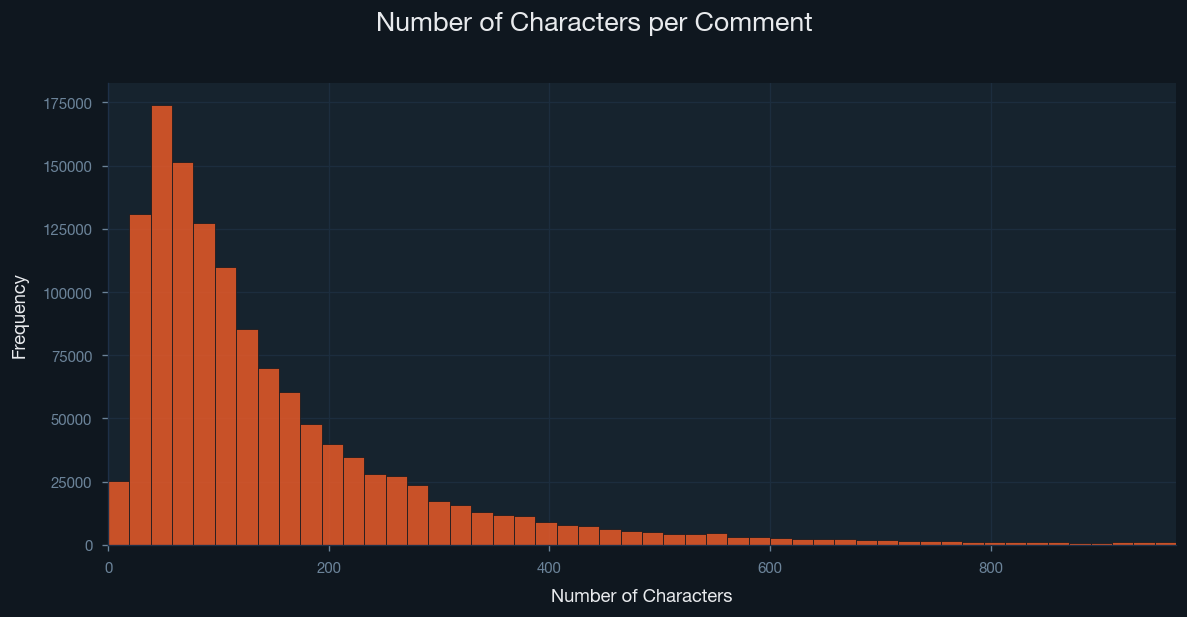

 Comments 
Average characters per comment : 164.2
Median characters per comment  : 104.0


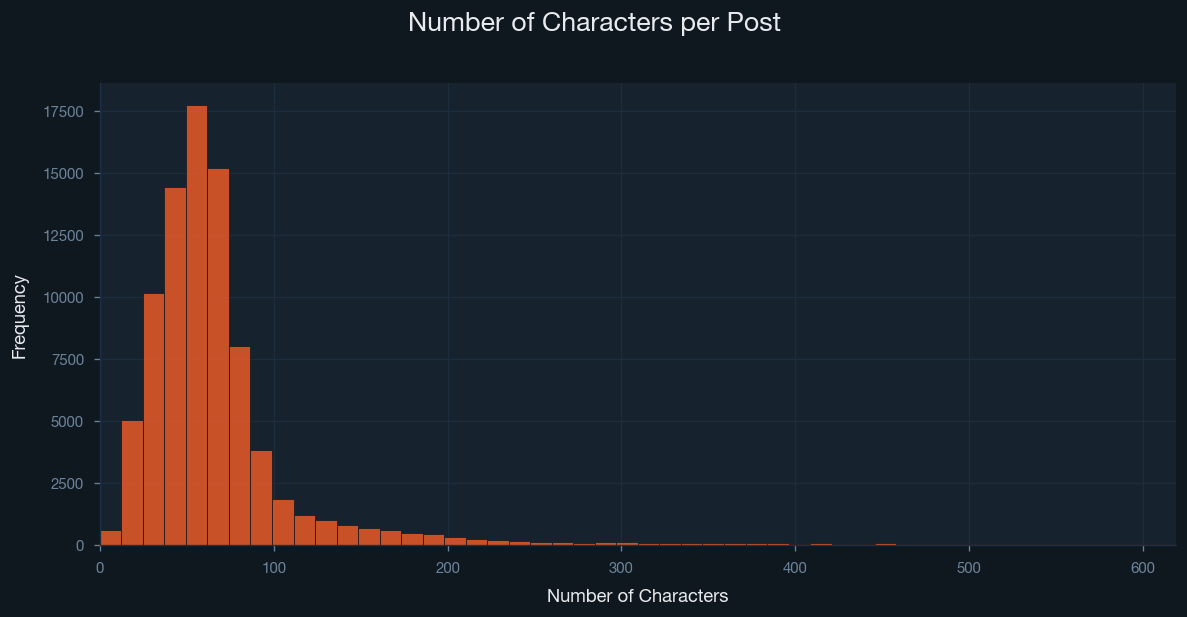

 Posts 
Average characters per post : 82.5
Median characters per post  : 58.0


In [ ]:
# Comments
char_counts_comments = comments['text_clean'].str.len()
p99_comments = np.percentile(char_counts_comments.dropna(), 99)

fig, ax = styled_fig(figsize=(10, 5), title='Number of Characters per Comment')
ax.hist(char_counts_comments, bins=50, range=(0, p99_comments),
        color=REDDIT_ORG, edgecolor=BG_DARK, alpha=0.85)
ax.set_xlim(0, p99_comments)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(" Comments ")
print(f"Average characters per comment : {char_counts_comments.mean():.1f}")
print(f"Median characters per comment  : {char_counts_comments.median():.1f}")

# Posts
char_counts_posts = posts['text_clean'].str.len()
p99_posts = np.percentile(char_counts_posts.dropna(), 99)

fig, ax = styled_fig(figsize=(10, 5), title='Number of Characters per Post')
ax.hist(char_counts_posts, bins=50, range=(0, p99_posts),
        color=REDDIT_ORG, edgecolor=BG_DARK, alpha=0.85)
ax.set_xlim(0, p99_posts)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(" Posts ")
print(f"Average characters per post : {char_counts_posts.mean():.1f}")
print(f"Median characters per post  : {char_counts_posts.median():.1f}")

Word count is a coarser but linguistically more meaningful measure of length than character count. It reflects how much content a user actually wrote, independent of word length. Reddit comments tend to cluster around very few words (reactions, one-liners), while post titles are constrained by platform norms to a moderate length. Again, the distribution is right-skewed and the x-axis is clipped at the 99th percentile to keep the bulk of the distribution clearly visible.

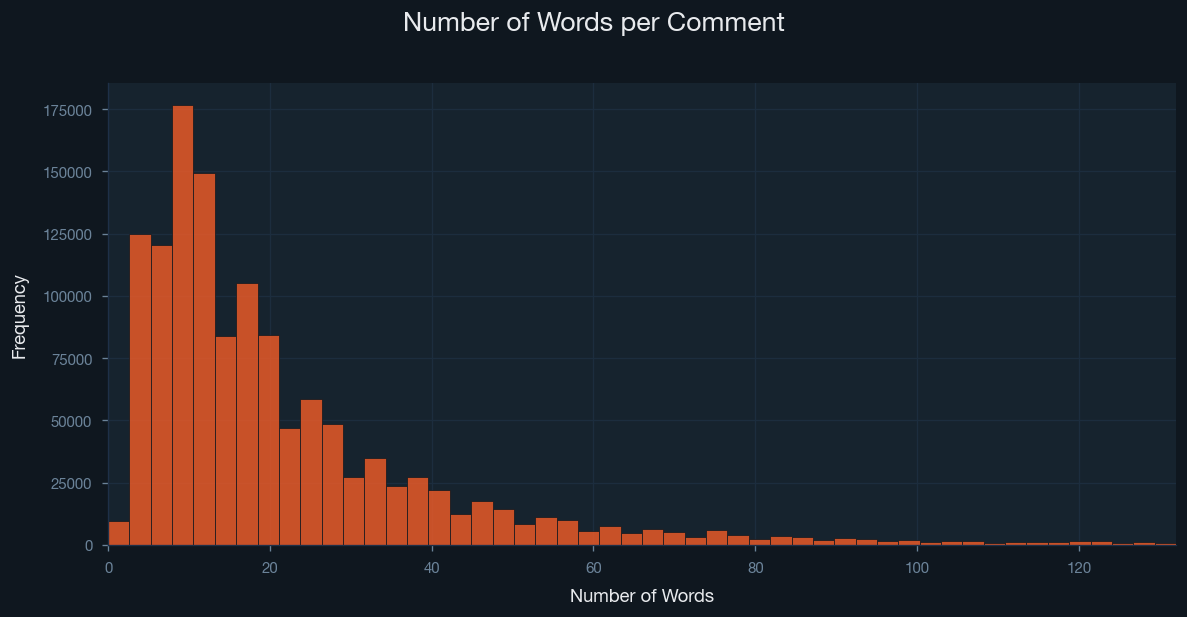

 Comments 
Average words per comment : 23.4
Median words per comment  : 15.0


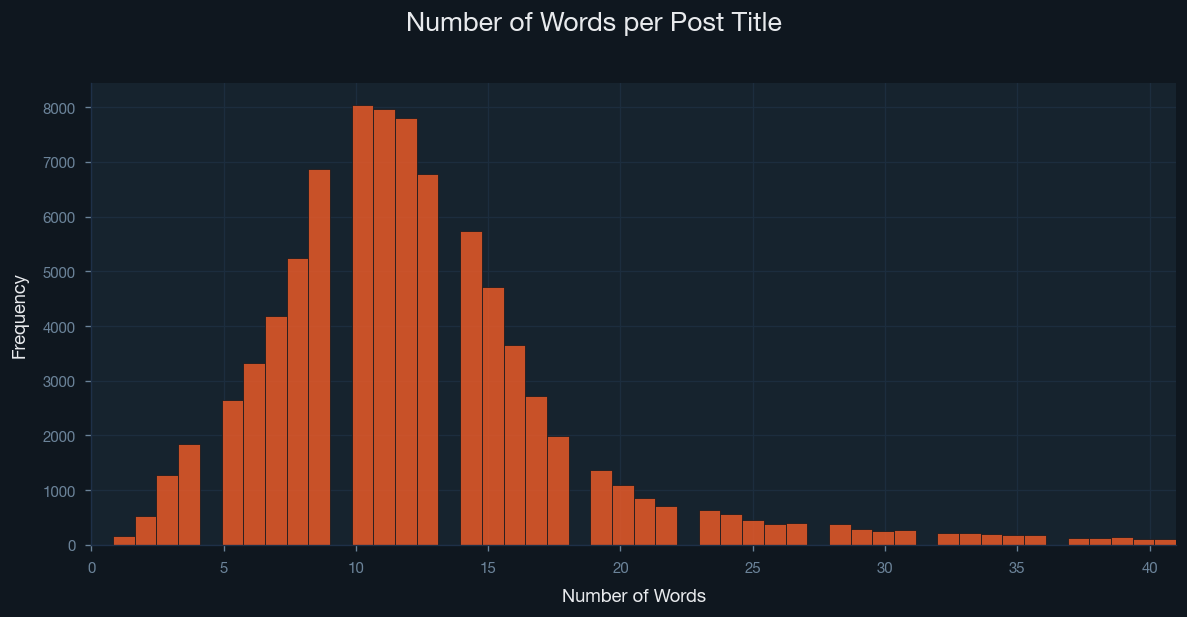

 Posts 
Average words per post title : 12.8
Median words per post title  : 12.0


In [ ]:
# Comments
word_counts_comments = comments['text_clean'].str.split().str.len()
p99_wc_comments = np.percentile(word_counts_comments.dropna(), 99)

fig, ax = styled_fig(figsize=(10, 5), title='Number of Words per Comment')
ax.hist(word_counts_comments, bins=50, range=(0, p99_wc_comments),
        color=REDDIT_ORG, edgecolor=BG_DARK, alpha=0.85)
ax.set_xlim(0, p99_wc_comments)
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(" Comments ")
print(f"Average words per comment : {word_counts_comments.mean():.1f}")
print(f"Median words per comment  : {word_counts_comments.median():.1f}")

# Posts — title column
word_counts_posts = posts['title'].str.split().str.len()
p99_wc_posts = np.percentile(word_counts_posts.dropna(), 99)

fig, ax = styled_fig(figsize=(10, 5), title='Number of Words per Post Title')
ax.hist(word_counts_posts, bins=50, range=(0, p99_wc_posts),
        color=REDDIT_ORG, edgecolor=BG_DARK, alpha=0.85)
ax.set_xlim(0, p99_wc_posts)
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(" Posts ")
print(f"Average words per post title : {word_counts_posts.mean():.1f}")
print(f"Median words per post title  : {word_counts_posts.median():.1f}")

## 2. Preprocessing Quality Check

To verify that the preprocessing pipeline behaves as expected, we compare raw and cleaned text for a sample document. The cleaning steps — lowercasing, stopword removal, punctuation stripping, and URL removal — should produce a compact, noise-free representation. This sanity check also helps spot any unintended side effects, such as meaningful words being accidentally dropped.

In [ ]:
# Compare examples before and after preprocessing — comments and posts
idx = 20

sample_df = pd.DataFrame([
    {
        "Source": "Comments",
        "Before preprocessing": str(comments['body'].iloc[idx])[:220],
        "After preprocessing": str(comments['text_clean'].iloc[idx])[:220],
    },
    {
        "Source": "Posts",
        "Before preprocessing": str(posts['title'].iloc[idx])[:220],
        "After preprocessing": str(posts['text_clean'].iloc[idx])[:220],
    },
])
sample_df["Chars before"] = sample_df["Before preprocessing"].str.len()
sample_df["Chars after"] = sample_df["After preprocessing"].str.len()

display(
    sample_df.style
    .set_caption("Preprocessing quality check — sample before/after")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY, "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY), ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK), ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("=" * 80)
print("COMMENTS — BEFORE PREPROCESSING:")
print("=" * 80)
print(str(comments['body'].iloc[idx])[:220])

print("=" * 80)
print("COMMENTS — AFTER PREPROCESSING:")
print("=" * 80)
print(str(comments['text_clean'].iloc[idx])[:220])

print("=" * 80)
print("POSTS — BEFORE PREPROCESSING:")
print("=" * 80)
print(str(posts['title'].iloc[idx])[:220])

print("=" * 80)
print("POSTS — AFTER PREPROCESSING:")
print("=" * 80)
print(str(posts['text_clean'].iloc[idx])[:220])

COMMENTS — BEFORE PREPROCESSING:
He has been the president behind the curtain the last 3-1/2 years
COMMENTS — AFTER PREPROCESSING:
president behind curtain last years
POSTS — BEFORE PREPROCESSING:
So Trump raped a child. What do?
POSTS — AFTER PREPROCESSING:
trump raped child


In [ ]:
def unique_word_count(texts):
    """Count unique words across all documents."""
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    elif isinstance(texts, str):
        texts = [texts]

    unique_words = set()
    for text in texts:
        words = str(text).split()
        unique_words.update(words)

    return len(unique_words)

# ── Compute preprocessing vocabulary stats ────────────────────────────────────
baseline_comments = unique_word_count(comments['body'])
clean_comments    = unique_word_count(comments['text_clean'])
baseline_posts    = unique_word_count(posts['title'])
clean_posts       = unique_word_count(posts['text_clean'])

prep_metrics = pd.DataFrame([
    {
        "Source": "Comments",
        "Unique words before": baseline_comments,
        "Unique words after": clean_comments,
    },
    {
        "Source": "Posts",
        "Unique words before": baseline_posts,
        "Unique words after": clean_posts,
    },
])
prep_metrics["Vocabulary reduction"] = prep_metrics["Unique words before"] - prep_metrics["Unique words after"]
prep_metrics["Reduction %"] = (
    1 - prep_metrics["Unique words after"] / prep_metrics["Unique words before"]
) * 100

display(
    prep_metrics.style
    .format({
        "Unique words before": "{:,.0f}",
        "Unique words after": "{:,.0f}",
        "Vocabulary reduction": "{:,.0f}",
        "Reduction %": "{:.2f}%",
    })
    .set_caption("Preprocessing outcome — vocabulary reduction")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY, "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY), ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK), ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("\nLaTeX table (preprocessing outcome):")
print(
    prep_metrics.to_latex(
        index=False,
        float_format="%.2f",
        caption="Preprocessing outcome for Reddit textual data.",
        label="tab:reddit_preprocessing_outcome",
    )
)

── Comments ──────────────────────────────────────
Baseline unique words (before) : 866,721
Cleaned unique words (after)   : 146,194
Vocabulary reduction           : 720,527  (83.1%)

── Posts ─────────────────────────────────────────
Baseline unique words (before) : 92,261
Cleaned unique words (after)   : 32,889
Vocabulary reduction           : 59,372  (64.4%)


## 3. TF-IDF Analysis

TF-IDF (Term Frequency–Inverse Document Frequency) transforms each document into a numeric vector that reflects how distinctive each word is within that document relative to the whole corpus. Words that appear frequently in a specific document but rarely across others get high scores, making TF-IDF a strong baseline for capturing topically distinctive vocabulary. The resulting Document-Term Matrix (DTM) is very sparse — most words appear in only a small fraction of documents — which is typical for text data at this scale.

In [ ]:
#  1. Repeated character normalizer 
def normalize_repeated_chars(text: str, max_repeat: int = 2) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(r'(.)\1{' + str(max_repeat) + r',}', r'\1' * max_repeat, text)

#  2. Load SymSpell dictionary when available 
if HAS_SYMSPELL:
    sym_spell = SymSpell(max_dictionary_edit_distance=2)
    dict_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
    sym_spell.load_dictionary(dict_path, term_index=0, count_index=1)
    print("SymSpell loaded.")
else:
    sym_spell = None
    print("SymSpell unavailable -> skipping spelling correction.")

#  3. Protected terms 
PROTECTED = {'trump', 'harris', 'biden', 'maga', 'gop', 'lol',
             'omg', 'tbh', 'ngl', 'imo', 'woke', 'kamala'}

#  4. Safe spell corrector 
def safe_correct(text: str) -> str:
    if not isinstance(text, str):
        return text
    if sym_spell is None:
        return text
    words = text.split()
    corrected = []
    for word in words:
        if word.lower() in PROTECTED:
            corrected.append(word)
        else:
            suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
            corrected.append(suggestions[0].term if suggestions else word)
    return ' '.join(corrected)

# ── 5. Apply to comments 
print("Processing comments …")
comments['text_norm'] = (
    comments['text_clean']
    .apply(normalize_repeated_chars)
    .apply(safe_correct)
)

print(" Comments")
print(comments[['text_clean', 'text_norm']].head(5))

# ── 6. Apply to posts 
print("\nProcessing posts …")
posts['text_norm'] = (
    posts['text_clean']
    .apply(normalize_repeated_chars)
    .apply(safe_correct)
)

print("\n Posts")
print(posts[['text_clean', 'text_norm']].head(5))

Processing comments …
 Comments
                                          text_clean  \
0                      joe first woman president wow   
1  turn campaign around going visit daughter ashl...   
2  exactly even walk across hot coals shards glas...   
3  love picked kamala political calculation blown...   
4  makes biden idiocy less idiotic trump people w...   

                                           text_norm  
0                      joe first woman president wow  
1  turn campaign around going visit daughter ashl...  
2  exactly even walk across hot coals shards glas...  
3  love picked kamala political calculation blown...  
4  makes biden idiocy less idiotic trump people w...  

Processing posts …

 Posts
                                          text_clean  \
0  economist editorial mocking biden image walker...   
1  economist blisters befuddled old man biden bru...   
2  going cnn watching past couple days largely an...   
3  disney heiress wealthy democratic donors say f

In [ ]:
#  Comments 
vectorizer_comments = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',
    lowercase=False,
    max_features=None
)

tfidf_comments = vectorizer_comments.fit_transform(comments['text_clean'])
feature_names_comments = vectorizer_comments.get_feature_names_out()

print(" Comments ")
print(f"DTM shape  : {tfidf_comments.shape}")
print(f"Documents  : {tfidf_comments.shape[0]}")
print(f"Terms      : {tfidf_comments.shape[1]}")
sparsity_comments = (1.0 - tfidf_comments.nnz / (tfidf_comments.shape[0] * tfidf_comments.shape[1])) * 100
print(f"Sparsity   : {sparsity_comments:.1f}%")

dtm_df_comments = pd.DataFrame(
    tfidf_comments[:5, :10].toarray(),
    columns=feature_names_comments[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df_comments)

#  Posts 
vectorizer_posts = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',
    lowercase=False,
    max_features=None
)

tfidf_posts = vectorizer_posts.fit_transform(posts['text_clean'])
feature_names_posts = vectorizer_posts.get_feature_names_out()

print("\n Posts ")
print(f"DTM shape  : {tfidf_posts.shape}")
print(f"Documents  : {tfidf_posts.shape[0]}")
print(f"Terms      : {tfidf_posts.shape[1]}")
sparsity_posts = (1.0 - tfidf_posts.nnz / (tfidf_posts.shape[0] * tfidf_posts.shape[1])) * 100
print(f"Sparsity   : {sparsity_posts:.1f}%")

dtm_df_posts = pd.DataFrame(
    tfidf_posts[:5, :10].toarray(),
    columns=feature_names_posts[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df_posts)

 Comments 
DTM shape  : (1307510, 146194)
Documents  : 1307510
Terms      : 146194
Sparsity   : 100.0%

Sample TF-IDF Matrix:
       aaa  aaaa  aaaaaa  aaaaaaa  aaaaaaaa  aaaaaaaaa  aaaaaaaaaa  \
Doc 1  0.0   0.0     0.0      0.0       0.0        0.0         0.0   
Doc 2  0.0   0.0     0.0      0.0       0.0        0.0         0.0   
Doc 3  0.0   0.0     0.0      0.0       0.0        0.0         0.0   
Doc 4  0.0   0.0     0.0      0.0       0.0        0.0         0.0   
Doc 5  0.0   0.0     0.0      0.0       0.0        0.0         0.0   

       aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaah  aaaaaaaaaaaaaaaaaaaaaaaaaaaaaahh  \
Doc 1                                   0.0                               0.0   
Doc 2                                   0.0                               0.0   
Doc 3                                   0.0                               0.0   
Doc 4                                   0.0                               0.0   
Doc 5                                   0.0     

The initial TF-IDF vocabulary contains many inflected forms of the same root word (e.g., *running*, *runs*, *ran*), which inflates the vocabulary size and increases sparsity. Applying a Snowball stemmer collapses these variants into a common stem, substantially shrinking the vocabulary. This makes the DTM denser and reduces noise in downstream models. The trade-off is reduced readability of individual terms — stemmed forms like *presid* or *idioci* are less intuitive — but the semantic signal is preserved.

In [ ]:
nltk.download('punkt', quiet=True)

stemmer = SnowballStemmer("english")

# ── Stemmer function ──────────────────────────────────────────────────────────
def stem_text(text: str) -> str:
    if not isinstance(text, str):
        return text
    return " ".join(stemmer.stem(word) for word in text.split())

# ── Apply to comments ─────────────────────────────────────────────────────────
print("Stemming comments …")
start = time.time()

tqdm.pandas(desc="Comments", unit=" docs")
comments['text_stemmed'] = comments['text_norm'].progress_apply(stem_text)

elapsed = time.time() - start
print(f"✓ Comments done in {elapsed/60:.1f} min")
print(comments[['text_norm', 'text_stemmed']].head(5))

# ── Apply to posts ────────────────────────────────────────────────────────────
print("\nStemming posts …")
start = time.time()

tqdm.pandas(desc="Posts", unit=" docs")
posts['text_stemmed'] = posts['text_norm'].progress_apply(stem_text)

elapsed = time.time() - start
print(f"✓ Posts done in {elapsed/60:.1f} min")
print(posts[['text_norm', 'text_stemmed']].head(5))

Stemming comments …


Comments: 100%|██████████| 1307510/1307510 [02:24<00:00, 9056.53 docs/s] 


✓ Comments done in 2.4 min
                                           text_norm  \
0                      joe first woman president wow   
1  turn campaign around going visit daughter ashl...   
2  exactly even walk across hot coals shards glas...   
3  love picked kamala political calculation blown...   
4  makes biden idiocy less idiotic trump people w...   

                                        text_stemmed  
0                         joe first woman presid wow  
1  turn campaign around go visit daughter ashley ...  
2   exact even walk across hot coal shard glass vote  
3  love pick kamala polit calcul blown face wors ...  
4  make biden idioci less idiot trump peopl well ...  

Stemming posts …


Posts: 100%|██████████| 85554/85554 [00:04<00:00, 17977.08 docs/s]

✓ Posts done in 0.1 min
                                           text_norm  \
0  economist editorial mocking biden image walker...   
1  economist blisters befuddled old man biden bru...   
2  going can watching past couple days largely an...   
3  disney heiress wealthy democratic donors say f...   
4  california delegate says black women blow part...   

                                        text_stemmed  
0  economist editori mock biden imag walker break...  
1  economist blister befuddl old man biden brutal...  
2  go can watch past coupl day larg anti biden fe...  
3  disney heiress wealthi democrat donor say fina...  
4  california deleg say black women blow parti de...  


In [ ]:
#  Comments 
vectorizer_comments = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',
    lowercase=False,
    max_features=None
)

tfidf_comments = vectorizer_comments.fit_transform(comments['text_stemmed'])
feature_names_comments = vectorizer_comments.get_feature_names_out()
sparsity_comments = (1.0 - tfidf_comments.nnz / (tfidf_comments.shape[0] * tfidf_comments.shape[1])) * 100

#  Posts 
vectorizer_posts = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',
    lowercase=False,
    max_features=None
)

tfidf_posts = vectorizer_posts.fit_transform(posts['text_stemmed'])
feature_names_posts = vectorizer_posts.get_feature_names_out()
sparsity_posts = (1.0 - tfidf_posts.nnz / (tfidf_posts.shape[0] * tfidf_posts.shape[1])) * 100

tfidf_summary = pd.DataFrame([
    {
        "Source": "Comments",
        "Documents": tfidf_comments.shape[0],
        "Terms": tfidf_comments.shape[1],
        "Sparsity %": sparsity_comments,
    },
    {
        "Source": "Posts",
        "Documents": tfidf_posts.shape[0],
        "Terms": tfidf_posts.shape[1],
        "Sparsity %": sparsity_posts,
    },
])

display(
    tfidf_summary.style
    .format({
        "Documents": "{:,.0f}",
        "Terms": "{:,.0f}",
        "Sparsity %": "{:.2f}%",
    })
    .set_caption("TF-IDF outcome — dimensionality and sparsity")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY, "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY), ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK), ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("\nLaTeX table (TF-IDF outcome):")
print(
    tfidf_summary.to_latex(
        index=False,
        float_format="%.2f",
        caption="TF-IDF outcome for Reddit comments and posts.",
        label="tab:reddit_tfidf_outcome",
    )
)

print("\nSample TF-IDF Matrix — Comments:")
dtm_df_comments = pd.DataFrame(
    tfidf_comments[:5, :10].toarray(),
    columns=feature_names_comments[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print(dtm_df_comments)

print("\nSample TF-IDF Matrix — Posts:")
dtm_df_posts = pd.DataFrame(
    tfidf_posts[:5, :10].toarray(),
    columns=feature_names_posts[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print(dtm_df_posts)

 Comments 
DTM shape  : (1307510, 51764)
Documents  : 1307510
Terms      : 51764
Sparsity   : 100.0%

Sample TF-IDF Matrix:
       aabeialsa  aabeiaoea  aacckktshuual  aachen  aadjrsxdagsvzeu  aagghh  \
Doc 1        0.0        0.0            0.0     0.0              0.0     0.0   
Doc 2        0.0        0.0            0.0     0.0              0.0     0.0   
Doc 3        0.0        0.0            0.0     0.0              0.0     0.0   
Doc 4        0.0        0.0            0.0     0.0              0.0     0.0   
Doc 5        0.0        0.0            0.0     0.0              0.0     0.0   

       aah  aahhooihh  aaiftbbchop  aanhpi  
Doc 1  0.0        0.0          0.0     0.0  
Doc 2  0.0        0.0          0.0     0.0  
Doc 3  0.0        0.0          0.0     0.0  
Doc 4  0.0        0.0          0.0     0.0  
Doc 5  0.0        0.0          0.0     0.0  

 Posts 
DTM shape  : (85554, 17006)
Documents  : 85554
Terms      : 17006
Sparsity   : 99.9%

Sample TF-IDF Matrix:
       aah  aa

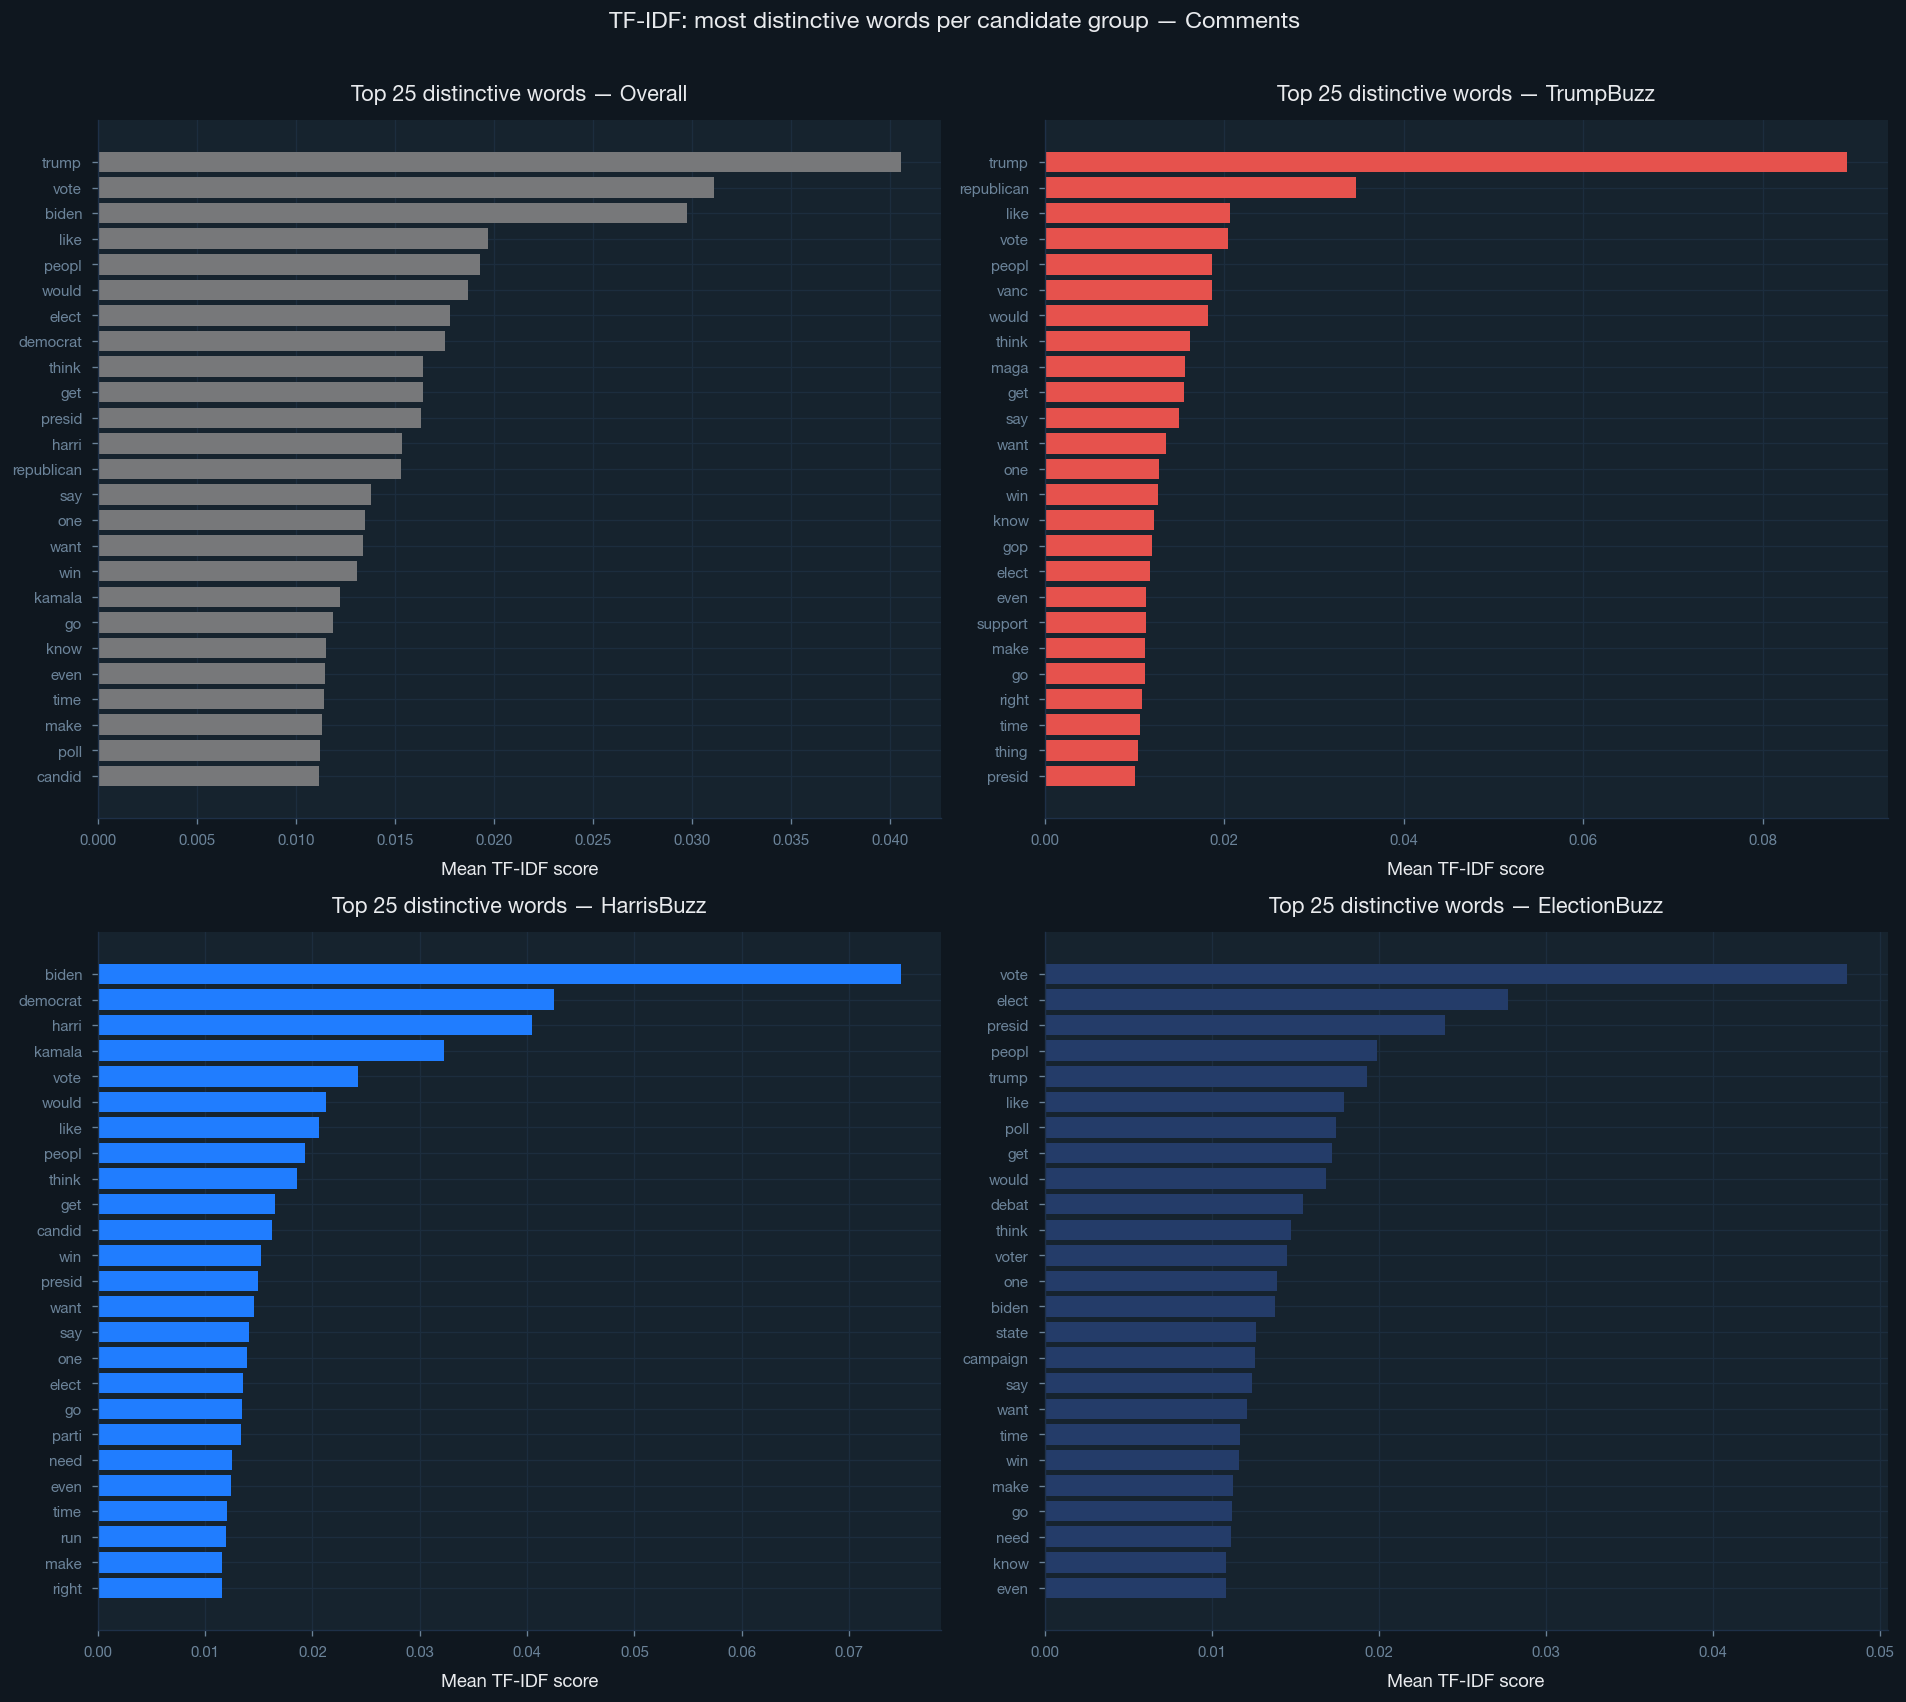

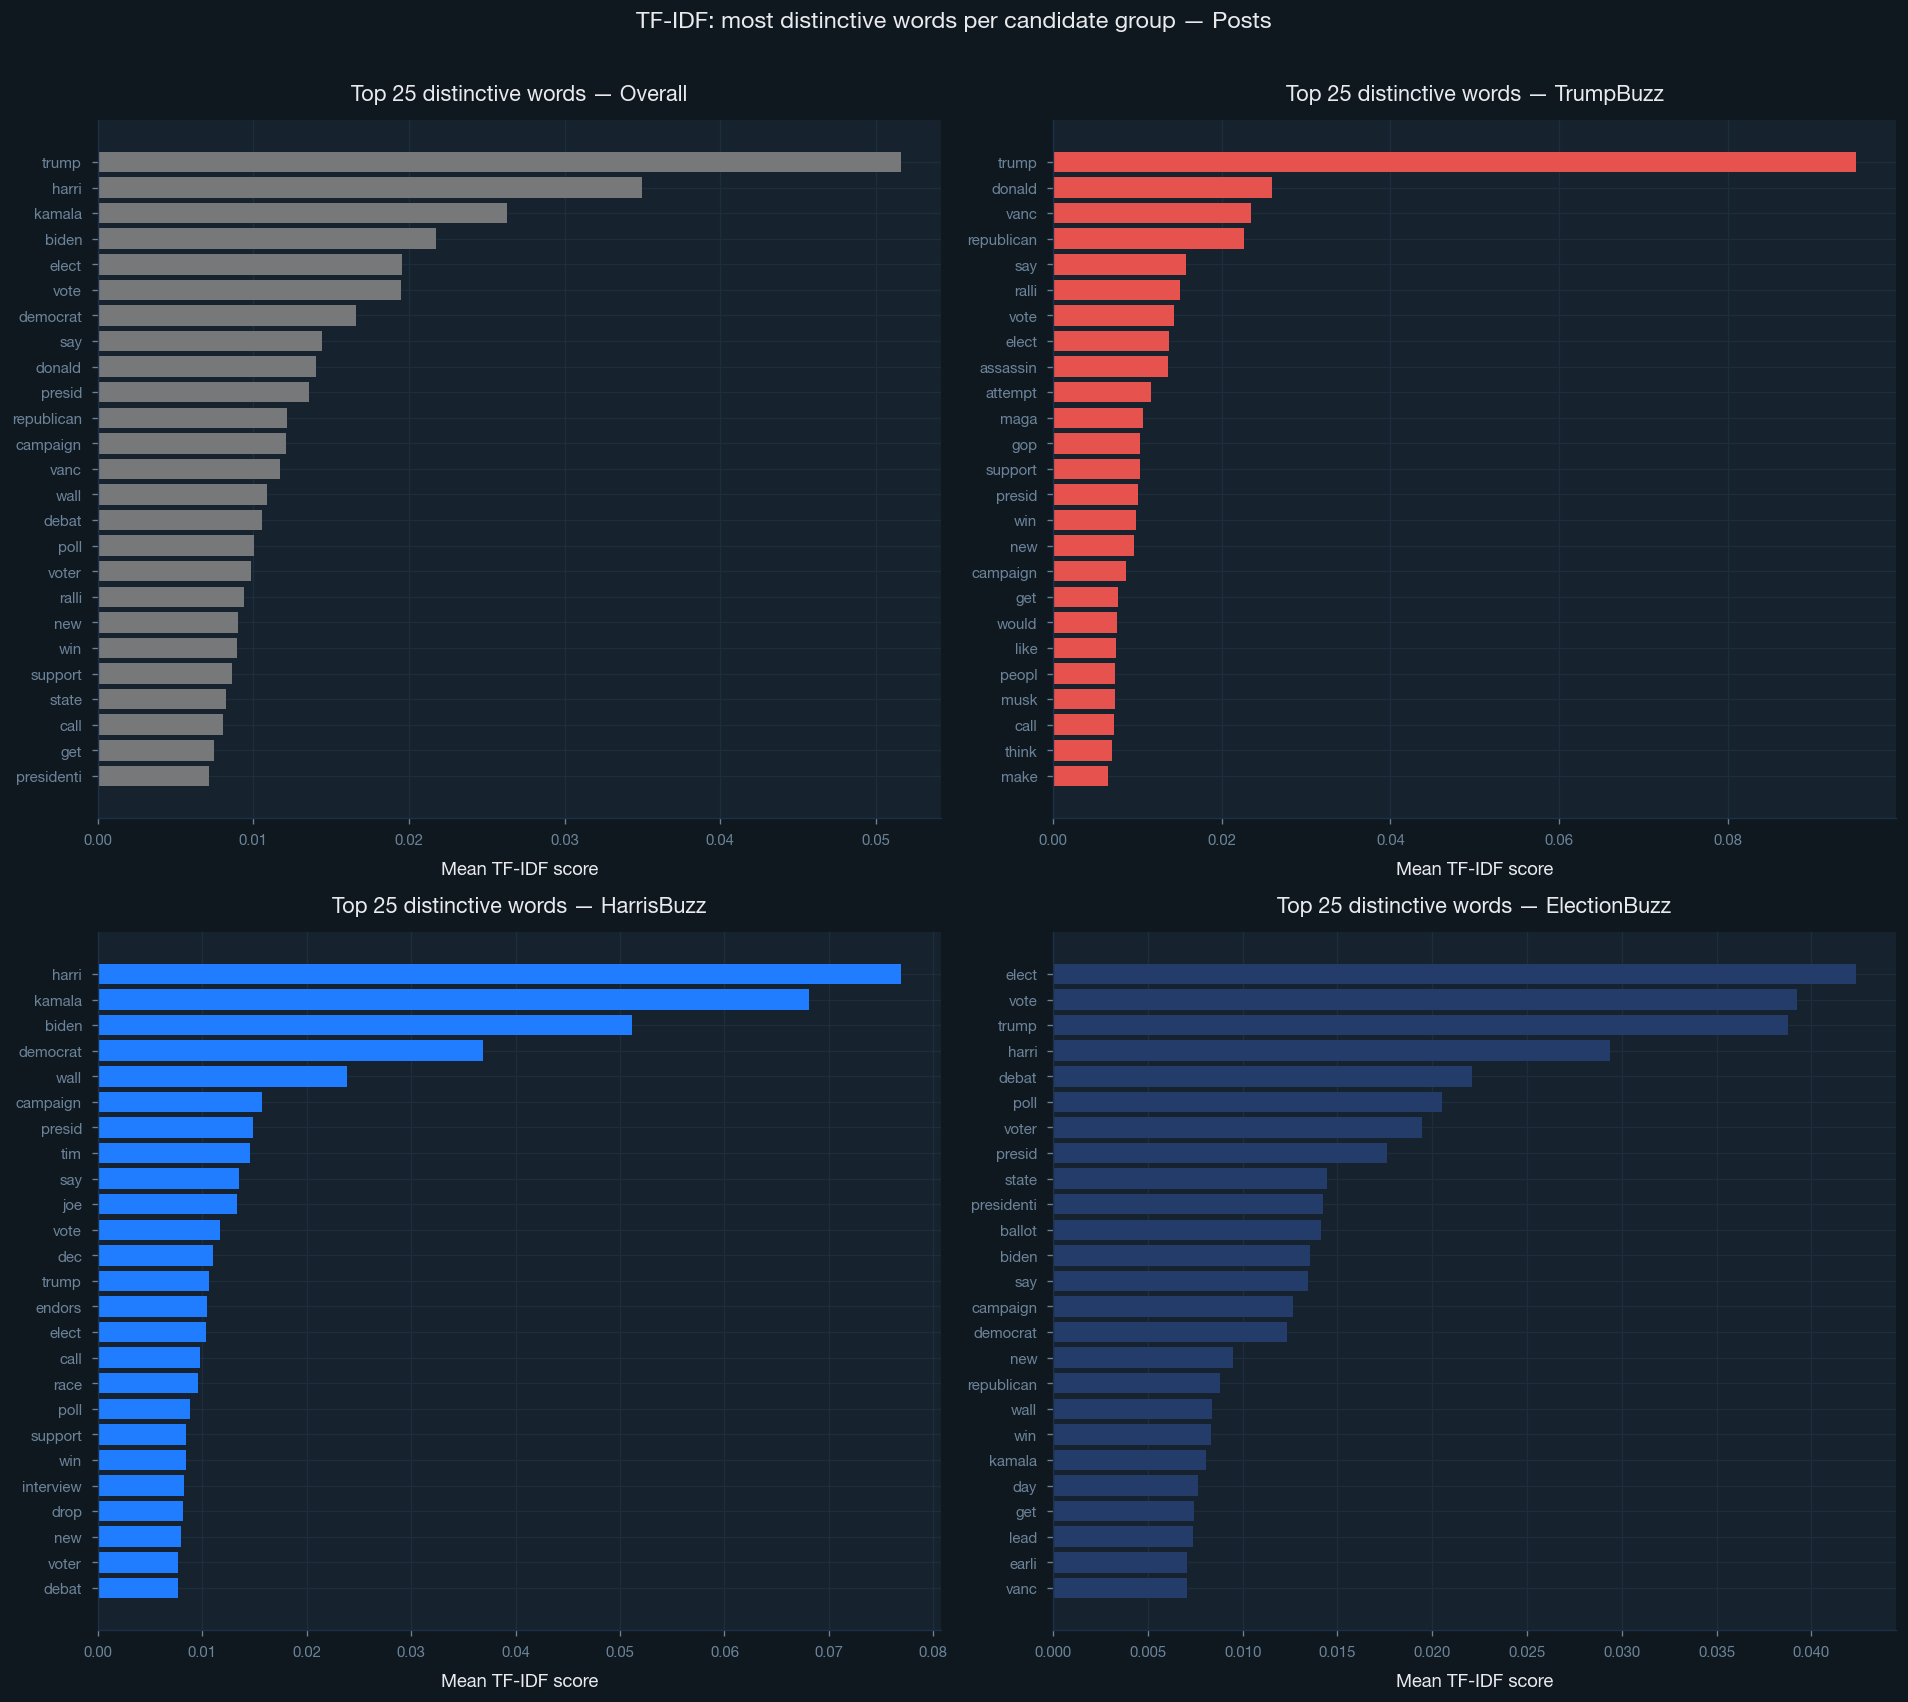

In [ ]:
GROUPS = ['Overall', 'TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
colors_bar = {
    'Overall':      OVERALL_BUZZ_COLOR,
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': ACCENT,
}

def print_latex_figure_snippet(filename, caption, label, width="0.95\\textwidth"):
    print("\\n\\begin{figure}[H]")
    print("    \\centering")
    print(f"    \\includegraphics[width={width}]{{{filename}}}")
    print(f"    \\caption{{{caption}}}")
    print(f"    \\label{{{label}}}")
    print("\\end{figure}")

def plot_distinctive_words(df, tfidf_matrix, feature_names, source_label):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.patch.set_facecolor(BG_DARK)

    for ax, group in zip(axes.flat, GROUPS):
        mask = (np.ones(len(df), dtype=bool) if group == 'Overall'
                else (df['candidate'] == group).values)

        mean_scores = tfidf_matrix[mask].mean(axis=0).A1
        top_idx     = mean_scores.argsort()[::-1][:25]

        ax.barh(feature_names[top_idx][::-1], mean_scores[top_idx][::-1],
                color=colors_bar[group])
        style_ax(ax, xlabel='Mean TF-IDF score',
                 title=f'Top 25 distinctive words — {group}', grid_axis='x')

    plt.suptitle(f'TF-IDF: most distinctive words per candidate group — {source_label}',
                 fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    out_file = LATEX_REDDIT_FIG_DIR / f"reddit_tfidf_distinctive_words_{source_label.lower()}.png"
    fig.savefig(out_file, dpi=300, bbox_inches='tight', facecolor=BG_DARK)
    print(f"Saved figure: {out_file}")

    print_latex_figure_snippet(
        filename=out_file.name,
        caption=f"Reddit TF-IDF distinctive words by buzz cluster ({source_label.lower()}).",
        label=f"fig:reddit_tfidf_distinctive_{source_label.lower()}"
    )

plot_distinctive_words(comments, tfidf_comments, feature_names_comments, source_label='Comments')
plot_distinctive_words(posts, tfidf_posts, feature_names_posts, source_label='Posts')

## 4. Latent Semantic Analysis (SVD)

Even after stemming, the TF-IDF matrix has tens of thousands of dimensions — far too many for most downstream models. Truncated SVD (the engine behind Latent Semantic Analysis) compresses this high-dimensional space into a small number of *latent concepts* that capture the main axes of variation in the corpus. Each concept is a weighted combination of terms that tend to co-occur, revealing thematic structure that individual word counts miss. The reduced representation is denser, faster to compute with, and less sensitive to lexical variation.

In [ ]:
print(comments['candidate'].unique())
print(posts['candidate'].unique())

['ElectionBuzz' 'HarrisBuzz' 'TrumpBuzz']
['HarrisBuzz' 'TrumpBuzz' 'ElectionBuzz']


In [ ]:
#  Comments 
n_docs_comments  = tfidf_comments.shape[0]
n_terms_comments = tfidf_comments.shape[1]
max_components_comments = min(n_docs_comments, n_terms_comments) - 1
target_components_comments = min(200, max_components_comments)

svd_comments = TruncatedSVD(
    n_components=target_components_comments,
    random_state=42
)
docs_concepts_comments = svd_comments.fit_transform(tfidf_comments)

#  Posts 
n_docs_posts  = tfidf_posts.shape[0]
n_terms_posts = tfidf_posts.shape[1]
max_components_posts = min(n_docs_posts, n_terms_posts) - 1
target_components_posts = min(200, max_components_posts)

svd_posts = TruncatedSVD(
    n_components=target_components_posts,
    random_state=42
)
docs_concepts_posts = svd_posts.fit_transform(tfidf_posts)

svd_summary = pd.DataFrame([
    {
        "Source": "Comments",
        "Original terms": n_terms_comments,
        "Max components": max_components_comments,
        "Used components": docs_concepts_comments.shape[1],
        "Reduction %": (1 - docs_concepts_comments.shape[1] / n_terms_comments) * 100,
    },
    {
        "Source": "Posts",
        "Original terms": n_terms_posts,
        "Max components": max_components_posts,
        "Used components": docs_concepts_posts.shape[1],
        "Reduction %": (1 - docs_concepts_posts.shape[1] / n_terms_posts) * 100,
    },
])

display(
    svd_summary.style
    .format({
        "Original terms": "{:,.0f}",
        "Max components": "{:,.0f}",
        "Used components": "{:,.0f}",
        "Reduction %": "{:.2f}%",
    })
    .set_caption("SVD outcome — compression from TF-IDF space")
    .set_properties(**{"background-color": BG_PANEL, "color": TEXT_PRIMARY, "border-color": SPINE_COLOR})
    .set_table_styles([
        {"selector": "caption", "props": [("color", TEXT_PRIMARY), ("font-weight", "bold"), ("font-size", "12pt")]},
        {"selector": "th", "props": [("background-color", BG_DARK), ("color", TEXT_PRIMARY), ("border-color", SPINE_COLOR)]},
        {"selector": "td", "props": [("border-color", SPINE_COLOR)]},
    ])
)

print("\nLaTeX table (SVD outcome):")
print(
    svd_summary.to_latex(
        index=False,
        float_format="%.2f",
        caption="SVD dimensionality reduction outcome for Reddit textual features.",
        label="tab:reddit_svd_outcome",
    )
)

print("\nComments")
print(f"Original matrix shape : {tfidf_comments.shape}")
print(f"Maximum components    : {max_components_comments}")
print(f"Reduced matrix shape  : {docs_concepts_comments.shape}")

print("\nPosts")
print(f"Original matrix shape : {tfidf_posts.shape}")
print(f"Maximum components    : {max_components_posts}")
print(f"Reduced matrix shape  : {docs_concepts_posts.shape}")

 Comments 
Original matrix shape : (1307510, 51764)
Maximum components    : 51763
Reduced matrix shape  : (1307510, 100)
Dimensionality reduction: 51764 → 100

 Posts 
Original matrix shape : (85554, 17006)
Maximum components    : 17005
Reduced matrix shape  : (85554, 100)
Dimensionality reduction: 17006 → 100


In [ ]:
#  Comments 
print(" Comments ")

print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {docs_concepts_comments.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(docs_concepts_comments[:5, :5])

print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_comments.singular_values_.shape}")
print(f"   First 10 values: {svd_comments.singular_values_[:10]}")

print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_comments.components_.shape}")
print(f"   Shows how terms contribute to each concept")

#  Posts 
print("\n Posts ")

print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {docs_concepts_posts.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(docs_concepts_posts[:5, :5])

print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_posts.singular_values_.shape}")
print(f"   First 10 values: {svd_posts.singular_values_[:10]}")

print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_posts.components_.shape}")
print(f"   Shows how terms contribute to each concept")

 Comments 
1. Document-by-Concept Matrix (U):
   Shape: (1307510, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 0.07860712 -0.03932033 -0.05246    -0.00255177 -0.02836487]
 [ 0.06942112 -0.0190181  -0.02022754 -0.01383606 -0.01242155]
 [ 0.06599733  0.10797646  0.01278044  0.0243043  -0.00385774]
 [ 0.07060659 -0.02343086 -0.01336852 -0.01680907 -0.00874192]
 [ 0.22299052 -0.09409089 -0.07137359  0.14522062  0.02657705]]

2. Singular Values (Σ - diagonal of sigma matrix):
   Shape: (100,)
   First 10 values: [162.63885778  89.34884125  79.52178795  75.2356228   71.07601599
  68.75247138  68.23696726  66.97150735  65.70447192  63.61186107]

3. Concept-by-Term Matrix (V^T):
   Shape: (100, 51764)
   Shows how terms contribute to each concept

 Posts 
1. Document-by-Concept Matrix (U):
   Shape: (85554, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 0.03780664  0.00162325

Each SVD component represents a latent semantic concept — an abstract topic defined by the words that load most strongly on it. The first concept typically captures the broadest shared theme in the corpus (here, general election discourse), while later concepts progressively separate more specific sub-topics. The sign of a term's loading indicates whether it is positively or negatively associated with that concept axis. Examining the top-weighted terms per concept lets us attach a human-interpretable label to each latent dimension before using them as features.

In [ ]:
def display_top_terms_per_concept(svd_model, feature_names, n_top=10, n_concepts=5):
    """Display top terms for each latent concept."""
    for i in range(min(n_concepts, svd_model.n_components)):
        component = svd_model.components_[i]
        top_indices = np.argsort(np.abs(component))[::-1][:n_top]
        top_terms   = [feature_names[idx] for idx in top_indices]
        top_weights = [component[idx] for idx in top_indices]

        print(f"\nConcept {i+1} (σ = {svd_model.singular_values_[i]:.3f}):")
        for term, weight in zip(top_terms, top_weights):
            print(f"  {term:20s} {weight:>8.4f}")

#  Comments 
print(" Comments ")
display_top_terms_per_concept(svd_comments, feature_names_comments, n_top=10, n_concepts=2)

#  Posts 
print("\n Posts ")
display_top_terms_per_concept(svd_posts, feature_names_posts, n_top=10, n_concepts=2)

 Comments 

Concept 1 (σ = 162.639):
  trump                  0.3099
  vote                   0.2829
  biden                  0.2536
  peopl                  0.1707
  like                   0.1606
  would                  0.1567
  think                  0.1379
  elect                  0.1353
  get                    0.1344
  democrat               0.1323

Concept 2 (σ = 89.349):
  vote                   0.8716
  trump                 -0.2647
  biden                 -0.2006
  debat                 -0.1027
  presid                -0.0991
  peopl                  0.0881
  blue                   0.0680
  campaign              -0.0507
  matter                 0.0484
  regist                 0.0474

 Posts 

Concept 1 (σ = 35.668):
  trump                  0.4737
  harri                  0.4060
  kamala                 0.3094
  vote                   0.1845
  biden                  0.1719
  donald                 0.1656
  elect                  0.1639
  say                    0.1370
  presid

The singular values quantify how much of the total variance in the DTM each concept captures. A scree plot shows where the explained variance per component levels off — the "elbow" — which guides the choice of how many components to retain. We also track cumulative explained variance to find the smallest number of concepts that still preserve a meaningful share (e.g., 80%) of the original information. Retaining too few components discards signal; retaining too many reintroduces noise and increases compute cost.

In [ ]:
def variance_report(svd_model, label):
    variance              = svd_model.singular_values_ ** 2
    total_variance        = np.sum(variance)
    explained_variance_ratio = variance / total_variance
    cumulative_variance   = np.cumsum(explained_variance_ratio)

    print(f" {label} ")
    print("Variance Explained:")
    print(f"{'Component':<12} {'Variance':<12} {'% Explained':<15} {'Cumulative %':<15}")
    print("-" * 60)
    for i in range(min(10, len(explained_variance_ratio))):
        print(f"{i+1:<12} {variance[i]:<12.4f} "
              f"{explained_variance_ratio[i]*100:<15.2f} "
              f"{cumulative_variance[i]*100:<15.2f}")

    print(f"\nFirst 3 components explain {cumulative_variance[2]*100:.1f}% of variance")
    print(f"First 5 components explain {cumulative_variance[4]*100:.1f}% of variance")
    print()

variance_report(svd_comments, "Comments")
variance_report(svd_posts,    "Posts")

 Comments 
Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            26451.3981   9.99            9.99           
2            7983.2154    3.01            13.00          
3            6323.7148    2.39            15.39          
4            5660.3989    2.14            17.53          
5            5051.8000    1.91            19.43          
6            4726.9023    1.78            21.22          
7            4656.2837    1.76            22.98          
8            4485.1828    1.69            24.67          
9            4317.0776    1.63            26.30          
10           4046.4689    1.53            27.83          

First 3 components explain 15.4% of variance
First 5 components explain 19.4% of variance

 Posts 
Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            1272.2160    7.27 

In [ ]:
def variance_plot(svd_model, label, line_color=DEMOCRAT):
    variance                 = svd_model.singular_values_ ** 2
    total_variance           = np.sum(variance)
    explained_variance_ratio = variance / total_variance
    cumulative_variance      = np.cumsum(explained_variance_ratio)

    # Show up to the 95% threshold (or all components if fewer)
    n95 = int(np.argmax(cumulative_variance >= 0.95)) + 1
    n_components_to_plot = min(n95, len(explained_variance_ratio))
    x = range(1, n_components_to_plot + 1)

    tick_step = max(1, n_components_to_plot // 10)

    fig, axes = styled_fig(1, 2, figsize=(14, 5),
                           title=f"SVD / Latent Semantic Analysis — {label}")

    # Plot 1: Variance per component (scree)
    axes[0].plot(x, explained_variance_ratio[:n_components_to_plot] * 100,
                 color=DEMOCRAT, linewidth=2)
    axes[0].set_xlabel("Component Number")
    axes[0].set_ylabel("% Variance Explained")
    axes[0].set_title("Scree Plot: Variance Explained per Component")
    axes[0].set_xticks(range(1, n_components_to_plot + 1, tick_step))

    # Plot 2: Cumulative variance
    axes[1].plot(x, cumulative_variance[:n_components_to_plot] * 100,
                 color=REPUBLICAN, linewidth=2)
    axes[1].axhline(80, color=NEUTRAL,    linestyle="--", linewidth=1.5, label="80% threshold")
    axes[1].axhline(90, color=TEXT_MUTED, linestyle="--", linewidth=1.5, label="90% threshold")
    axes[1].axhline(95, color=ACCENT,     linestyle="--", linewidth=1.5, label="95% threshold")
    axes[1].set_xlabel("Component Number")
    axes[1].set_ylabel("Cumulative % Variance Explained")
    axes[1].set_title("Cumulative Variance Explained")
    axes[1].set_xticks(range(1, n_components_to_plot + 1, tick_step))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Thresholds
    print(f" {label} ")
    for threshold in [0.80, 0.90, 0.95]:
        n_comp = np.argmax(cumulative_variance >= threshold) + 1
        print(f"  {threshold*100:.0f}% variance explained with {n_comp} components")
    print()

variance_plot(svd_comments, "Comments")
variance_plot(svd_posts,    "Posts")


In [ ]:
#  Comments 
variance_comments      = svd_comments.singular_values_ ** 2
cumvar_comments        = np.cumsum(variance_comments / np.sum(variance_comments))
n_optimal_comments     = np.argmax(cumvar_comments >= 0.80) + 1

print(" Comments ")
print(f"Using {n_optimal_comments} components "
      f"(explains {cumvar_comments[n_optimal_comments-1]*100:.1f}% of variance)")

lsa_comments          = TruncatedSVD(n_components=n_optimal_comments, random_state=42)
documents_lsa_comments = lsa_comments.fit_transform(tfidf_comments)

print(f"Original dimensionality : {tfidf_comments.shape[1]} terms")
print(f"Reduced dimensionality  : {documents_lsa_comments.shape[1]} concepts")
print(f"Dimensionality reduction: "
      f"{(1 - documents_lsa_comments.shape[1]/tfidf_comments.shape[1])*100:.1f}%")

#  Posts 
variance_posts         = svd_posts.singular_values_ ** 2
cumvar_posts           = np.cumsum(variance_posts / np.sum(variance_posts))
n_optimal_posts        = np.argmax(cumvar_posts >= 0.80) + 1

print("\n Posts ")
print(f"Using {n_optimal_posts} components "
      f"(explains {cumvar_posts[n_optimal_posts-1]*100:.1f}% of variance)")

lsa_posts              = TruncatedSVD(n_components=n_optimal_posts, random_state=42)
documents_lsa_posts    = lsa_posts.fit_transform(tfidf_posts)

print(f"Original dimensionality : {tfidf_posts.shape[1]} terms")
print(f"Reduced dimensionality  : {documents_lsa_posts.shape[1]} concepts")
print(f"Dimensionality reduction: "
      f"{(1 - documents_lsa_posts.shape[1]/tfidf_posts.shape[1])*100:.1f}%")

 Comments 
Using 67 components (explains 80.4% of variance)
Original dimensionality : 51764 terms
Reduced dimensionality  : 67 concepts
Dimensionality reduction: 99.9%

 Posts 
Using 66 components (explains 80.5% of variance)
Original dimensionality : 17006 terms
Reduced dimensionality  : 66 concepts
Dimensionality reduction: 99.6%


In [ ]:
print(comments.columns.tolist())
print(posts.columns.tolist())

['id', 'author', 'created_utc', 'subreddit', 'body', 'score', 'permalink', 'text', 'detected_lang', 'text_clean', 'words', 'word_count', 'candidate', 'text_norm', 'text_stemmed']
['id', 'author', 'created_utc', 'subreddit', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'permalink', 'text', 'detected_lang', 'text_clean', 'words', 'word_count', 'candidate', 'text_norm', 'text_stemmed']


In [ ]:
print(comments['created_utc'].dtype)
print(comments['created_utc'].head(3))

datetime64[ms, UTC]
0   2024-07-05 00:03:52+00:00
1   2024-07-05 00:06:59+00:00
2   2024-07-05 00:07:45+00:00
Name: created_utc, dtype: datetime64[ms, UTC]


── Comments: Top terms per concept ───────────────────────────────
  Concept  1 : trump, vote, biden, peopl, like
  Concept  2 : vote, trump, biden, debat, presid
  Concept  3 : trump, biden, pleas, harri, concern
  Concept  4 : biden, republican, democrat, trump, vote
  Concept  5 : pleas, democrat, trump, concern, biden
  Concept  6 : elect, republican, poll, harri, win
  Concept  7 : presid, poll, win, democrat, elect
  Concept  8 : elect, harri, presid, kamala, debat
  Concept  9 : harri, peopl, democrat, poll, win
  Concept 10 : poll, presid, elect, republican, peopl



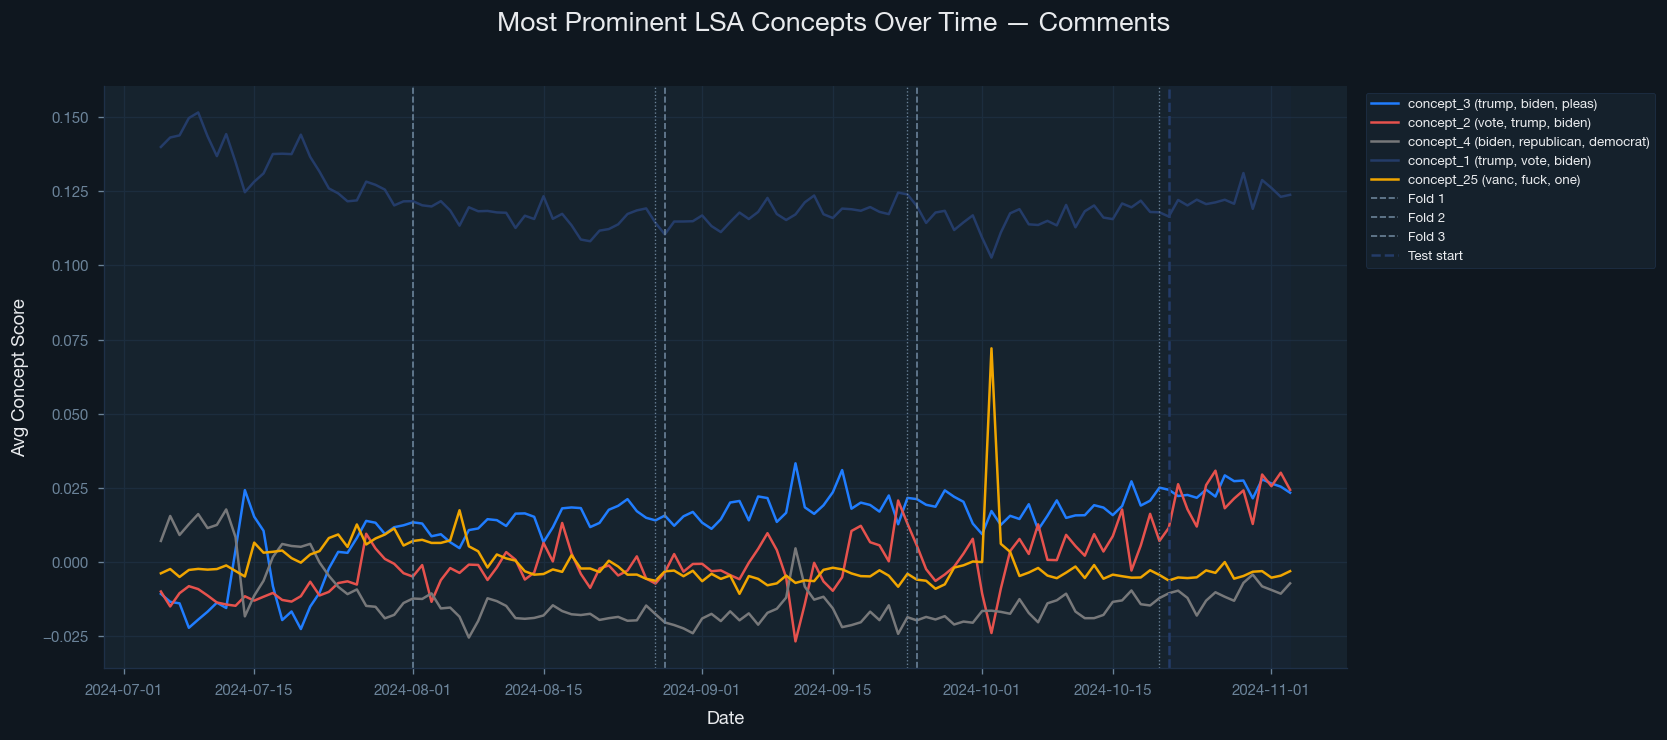

── Posts: Top terms per concept ───────────────────────────────
  Concept  1 : trump, harri, kamala, vote, biden
  Concept  2 : harri, kamala, trump, vote, donald
  Concept  3 : vote, trump, donald, elect, democrat
  Concept  4 : biden, vote, joe, democrat, kamala
  Concept  5 : elect, vote, win, biden, poll
  Concept  6 : wall, tim, vanc, debat, biden
  Concept  7 : democrat, republican, vote, biden, wall
  Concept  8 : presid, poll, debat, kamala, elect
  Concept  9 : presid, poll, debat, wall, state
  Concept 10 : presid, debat, assassin, attempt, vanc



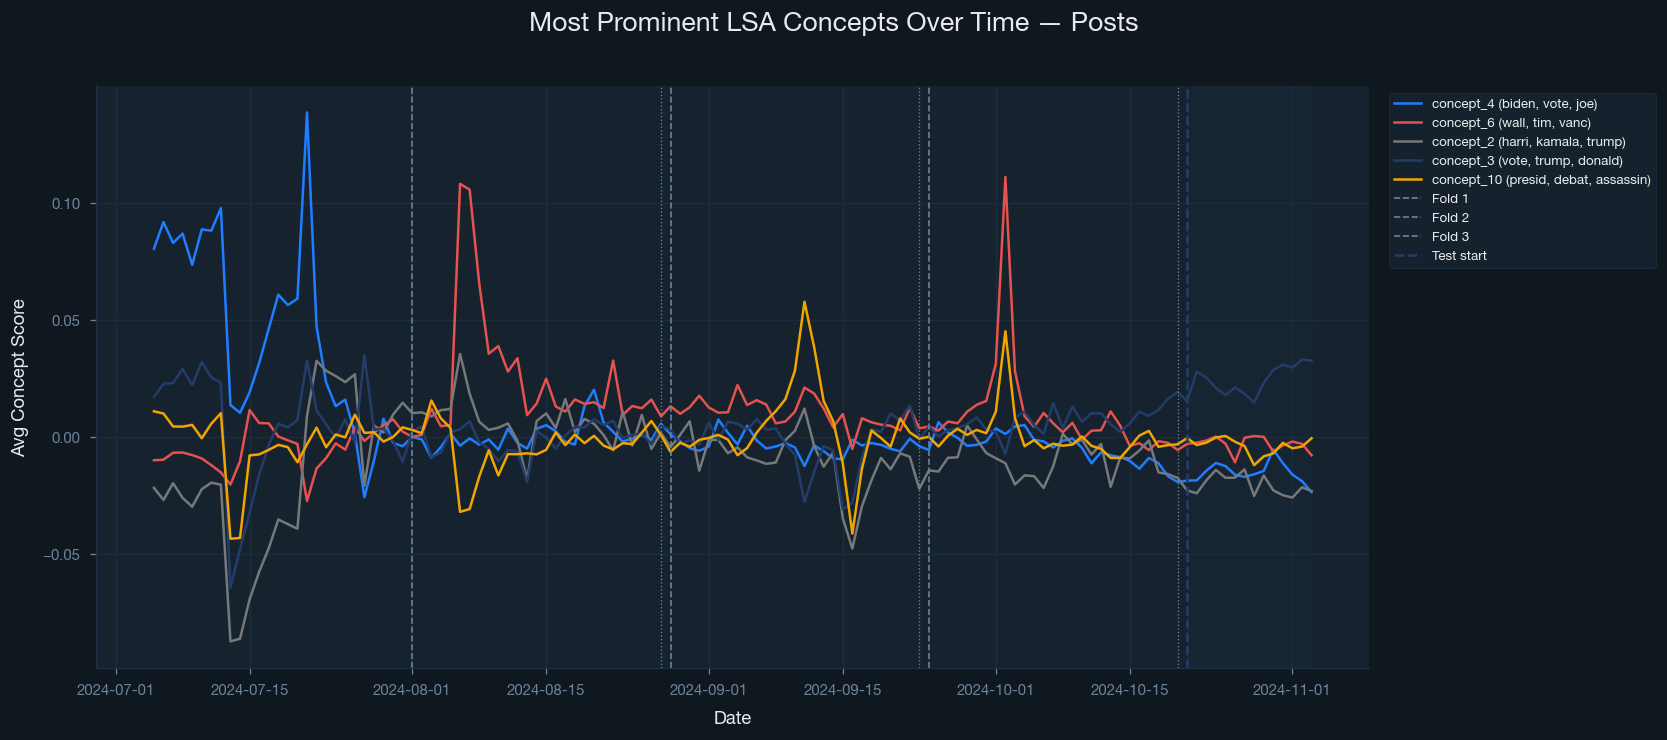

In [ ]:
def lsa_time_series(documents_lsa, lsa_model, vectorizer, df, label, n_splits=3, gap=1, test_days=14):

    # ── 1. Display concept themes ─────────────────────────────────────────────
    print(f"── {label}: Top terms per concept ───────────────────────────────")
    feature_names = vectorizer.get_feature_names_out()
    n_concepts_to_show = min(10, lsa_model.n_components)
    for i in range(n_concepts_to_show):
        component = lsa_model.components_[i]
        top_terms = [feature_names[j]
                     for j in np.argsort(np.abs(component))[::-1][:5]]
        print(f"  Concept {i+1:>2} : {', '.join(top_terms)}")
    print()

    # ── 2. Build LSA dataframe with date ──────────────────────────────────────
    lsa_cols = [f'concept_{i+1}' for i in range(lsa_model.n_components)]
    lsa_df   = pd.DataFrame(documents_lsa, columns=lsa_cols, index=df.index)
    lsa_df['date'] = df['created_utc'].dt.tz_convert(None).dt.normalize()

    # ── 3. Daily average per concept ──────────────────────────────────────────
    daily_concepts = lsa_df.groupby('date')[lsa_cols].mean()
    top_concepts   = daily_concepts.var().nlargest(5).index.tolist()

    # ── 4. Fold boundaries ────────────────────────────────────────────────────
    folds            = get_cv_folds(daily_concepts.reset_index(),
                                    n_splits=n_splits, gap=gap, test_days=test_days)
    tv_idx, _        = get_test_split(daily_concepts.reset_index(),
                                      test_days=test_days)

    dates      = daily_concepts.index
    test_start = dates[tv_idx[-1] + 1]

    fold_val_starts, fold_val_ends = [], []
    for train_idx, val_idx in folds:
        fold_val_starts.append(dates[val_idx[0]])
        fold_val_ends.append(dates[val_idx[-1]])

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    concept_colors = [OVERALL_BUZZ_COLOR, DEMOCRAT, REPUBLICAN, ACCENT, NEUTRAL]

    fig, ax = styled_fig(figsize=(14, 6),
                         title=f'Most Prominent LSA Concepts Over Time — {label}')

    for concept, color in zip(top_concepts, concept_colors):
        idx       = int(concept.split('_')[1]) - 1
        component = lsa_model.components_[idx]
        top_terms = [feature_names[j]
                     for j in np.argsort(np.abs(component))[::-1][:3]]
        label_str = f"{concept} ({', '.join(top_terms)})"
        ax.plot(daily_concepts.index, daily_concepts[concept],
                color=color, linewidth=1.8, label=label_str)

    # Fold boundaries
    for i, (val_start, val_end) in enumerate(zip(fold_val_starts, fold_val_ends), 1):
        ax.axvline(val_start, color=TEXT_MUTED, linestyle='--', linewidth=1,
                   label=f'Fold {i}')
        ax.axvline(val_end, color=TEXT_MUTED, linestyle=':', linewidth=0.8)

    # Test boundary
    ax.axvline(test_start, color=ACCENT, linestyle='--', linewidth=1.5, label='Test start')
    ax.axvspan(test_start, dates[-1], alpha=0.08, color=ACCENT)

    style_ax(ax, xlabel='Date', ylabel='Avg Concept Score',
             title=f'Most Prominent LSA Concepts Over Time — {label}', grid_axis='both')

    # Legend at the bottom
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=2,
        facecolor=BG_PANEL,
        edgecolor=SPINE_COLOR,
        labelcolor=TEXT_PRIMARY,
        fontsize=8,
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# ── Run for comments and posts ────────────────────────────────────────────────
lsa_time_series(
    documents_lsa_comments, lsa_comments, vectorizer_comments,
    comments, label="Comments"
)

lsa_time_series(
    documents_lsa_posts, lsa_posts, vectorizer_posts,
    posts, label="Posts"
)

## 5. Term Frequency Over Time

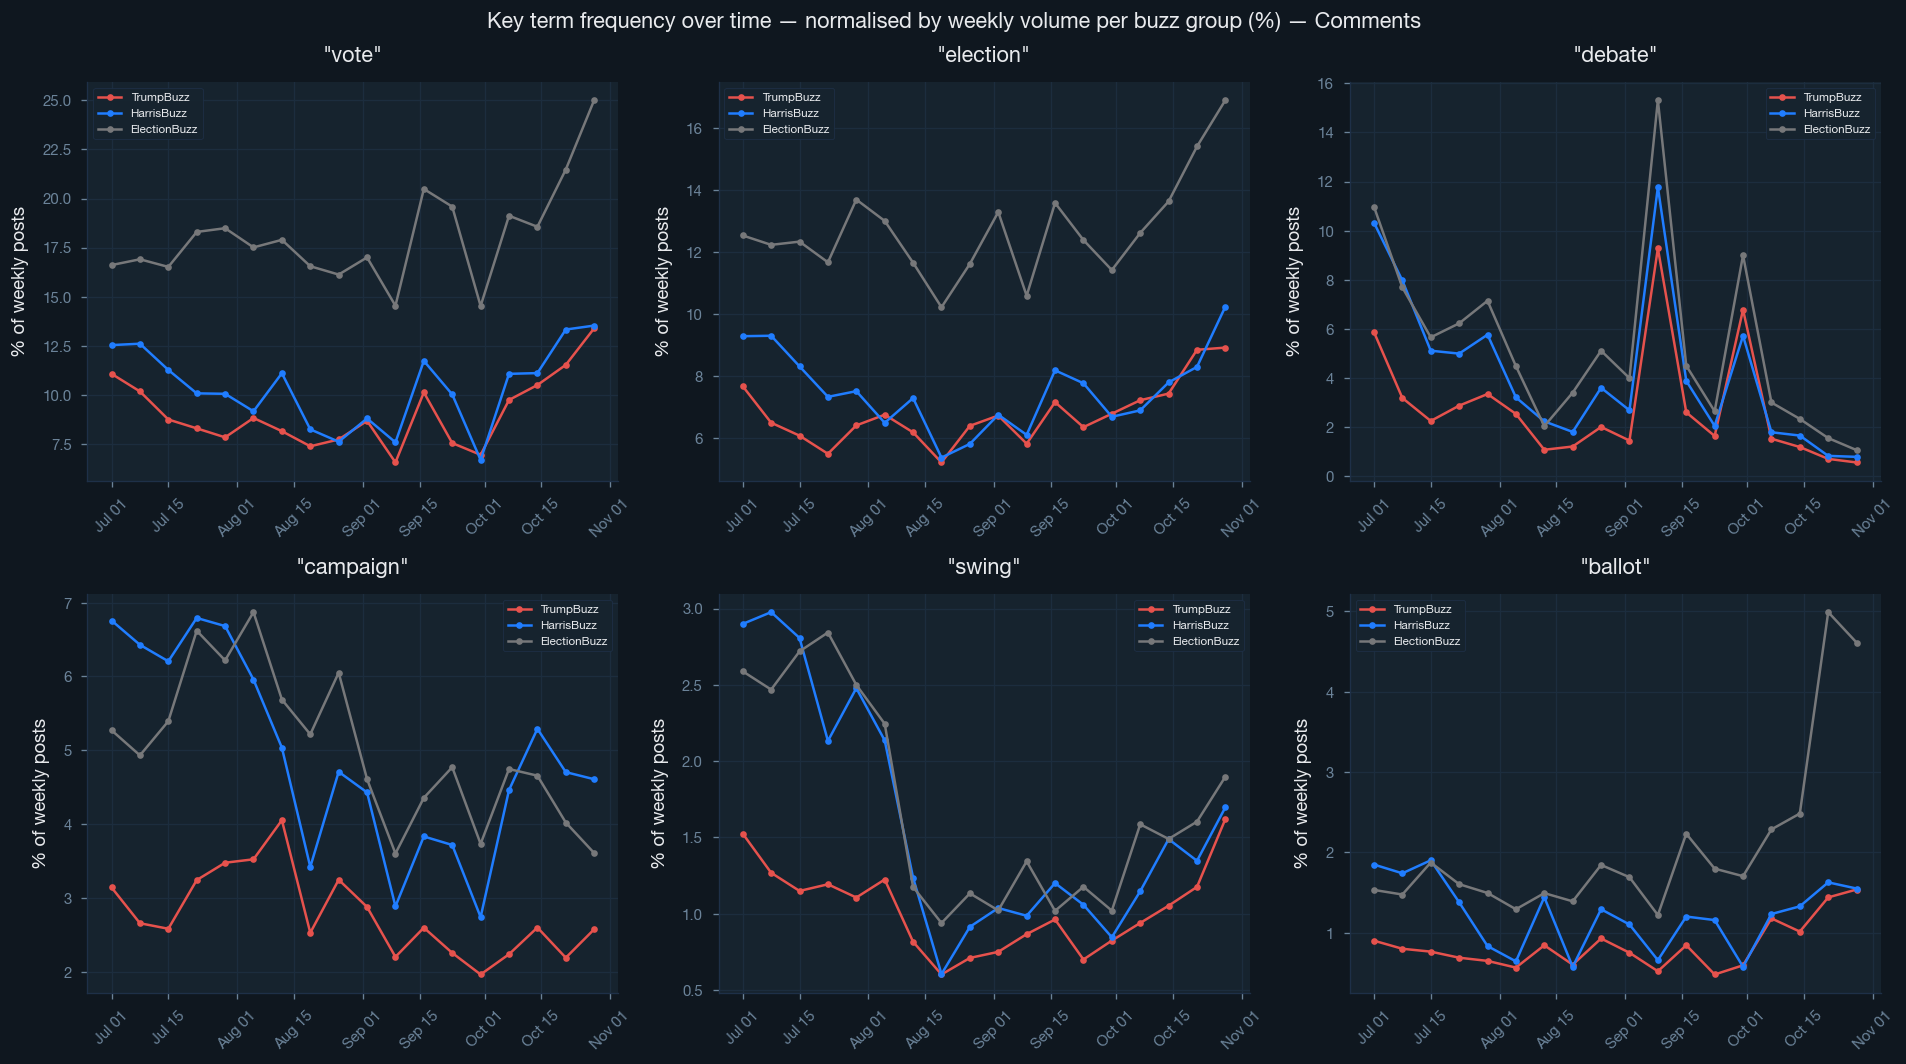

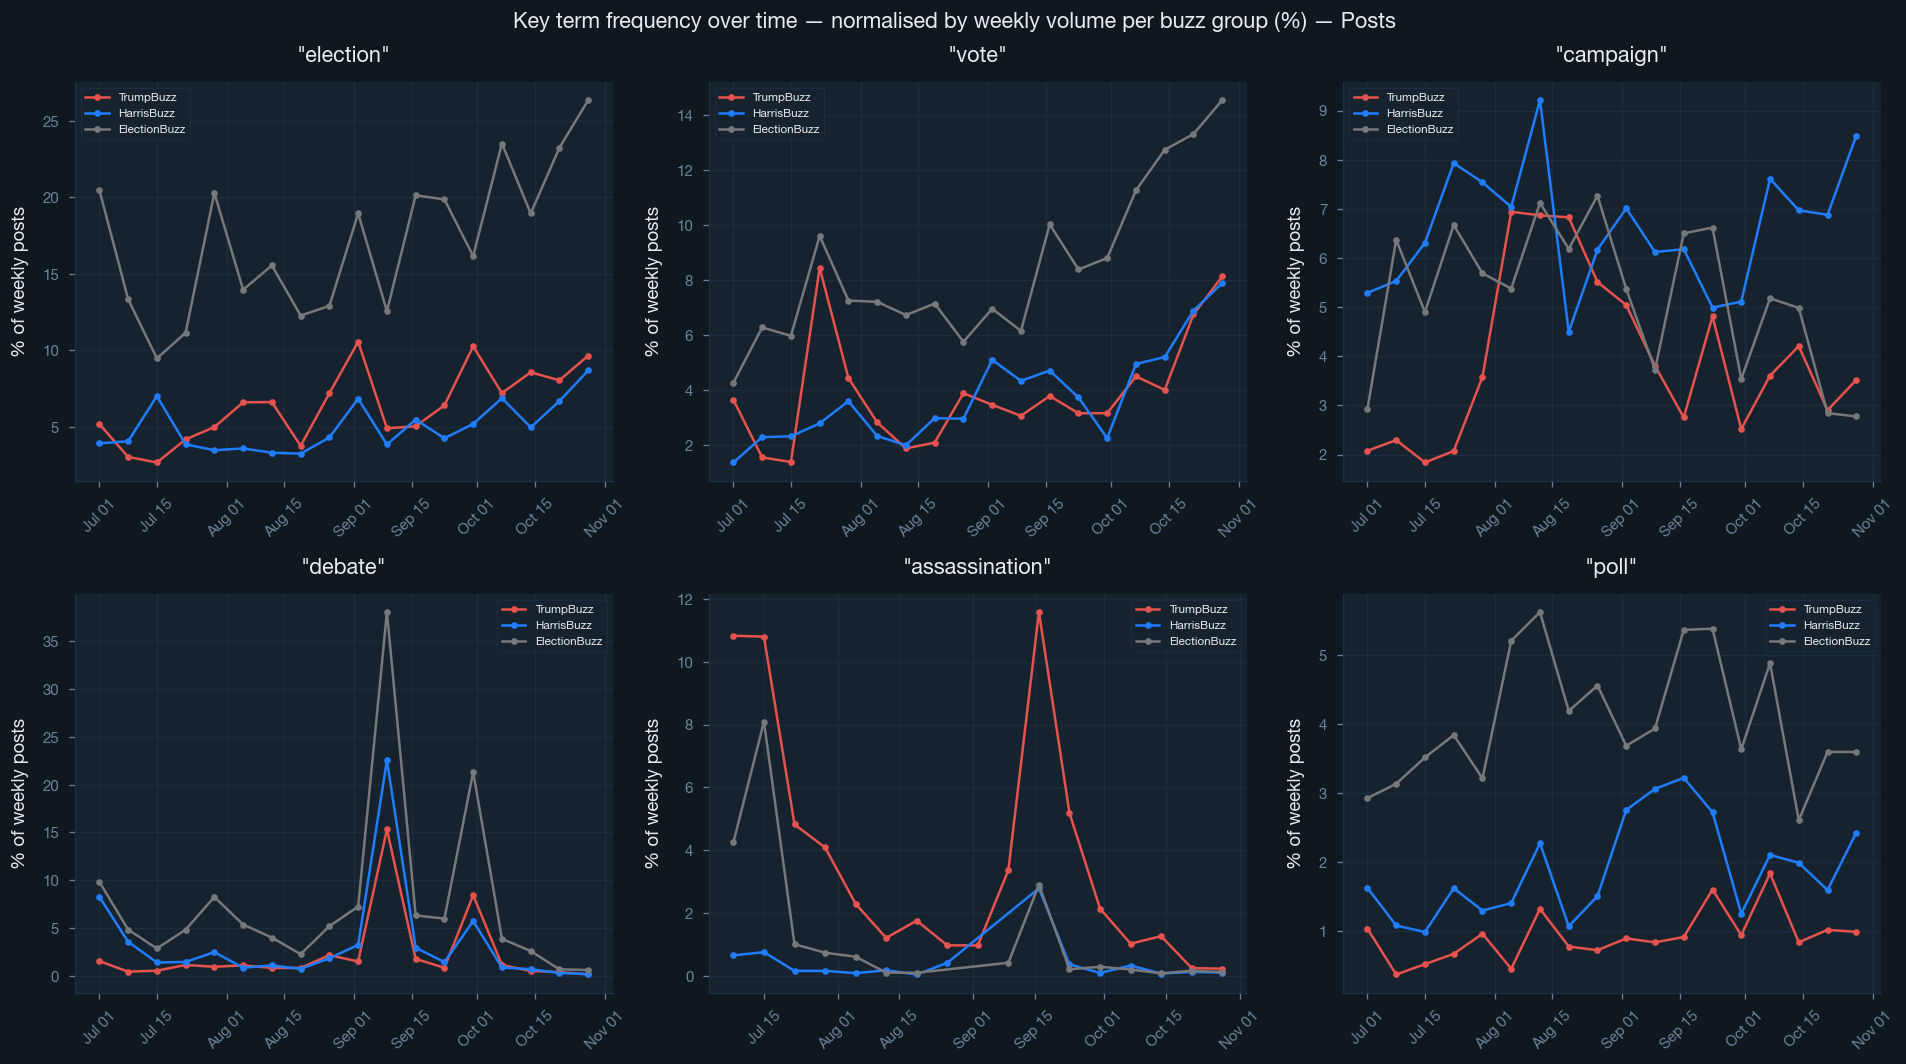

In [ ]:
colors_line = {
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,
}

TRACK_TERMS = [
    'debate', 'poll', 'abortion', 'immigration', 'economy',
    'campaign', 'vote', 'election', 'swing', 'battleground',
    'conviction', 'assassination', 'concede', 'ballot', 'tariff'
]

def term_frequency_plot(df, label):

    # ── Weekly totals per buzz group ──────────────────────────────────────────
    df = df.copy()
    df['week'] = (df['created_utc']
                  .dt.tz_convert(None)
                  .dt.to_period('W')
                  .dt.start_time)

    weekly_totals = (
        df.groupby(['week', 'candidate'])
        .size()
        .reset_index(name='total')
    )

    # ── Count term occurrences per week per buzz group ────────────────────────
    results = []
    for term in TRACK_TERMS:
        mask   = df['text_norm'].str.contains(r'\b' + term + r'\b',
                                               regex=True, na=False)
        weekly = (df[mask]
                  .groupby(['week', 'candidate'])
                  .size()
                  .reset_index(name='count'))
        weekly = weekly.merge(weekly_totals, on=['week', 'candidate'])
        weekly['share'] = weekly['count'] / weekly['total']
        weekly['term']  = term
        results.append(weekly)

    term_df   = pd.concat(results, ignore_index=True)
    top_terms = term_df.groupby('term')['count'].sum().nlargest(6).index.tolist()

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor(BG_DARK)

    for ax, term in zip(axes.flat, top_terms):
        ax.set_facecolor(BG_PANEL)
        subset = term_df[term_df['term'] == term]

        for group, color in colors_line.items():
            data = subset[subset['candidate'] == group]
            if not data.empty:
                ax.plot(data['week'], data['share'] * 100,
                        color=color, marker='o', ms=3,
                        linewidth=1.5, label=group)

        ax.set_title(f'"{term}"', color=TEXT_PRIMARY, fontweight='bold')
        ax.set_ylabel('% of weekly posts', color=TEXT_PRIMARY)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.tick_params(axis='x', rotation=45, colors=TEXT_MUTED)
        ax.tick_params(axis='y', colors=TEXT_MUTED)
        ax.legend(fontsize=7)

    plt.suptitle(
        f'Key term frequency over time — normalised by weekly volume per buzz group (%) — {label}',
        color=TEXT_PRIMARY, fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

# ── Run for comments and posts ────────────────────────────────────────────────
term_frequency_plot(comments, label="Comments")
term_frequency_plot(posts,    label="Posts")

## 6. Word Clouds

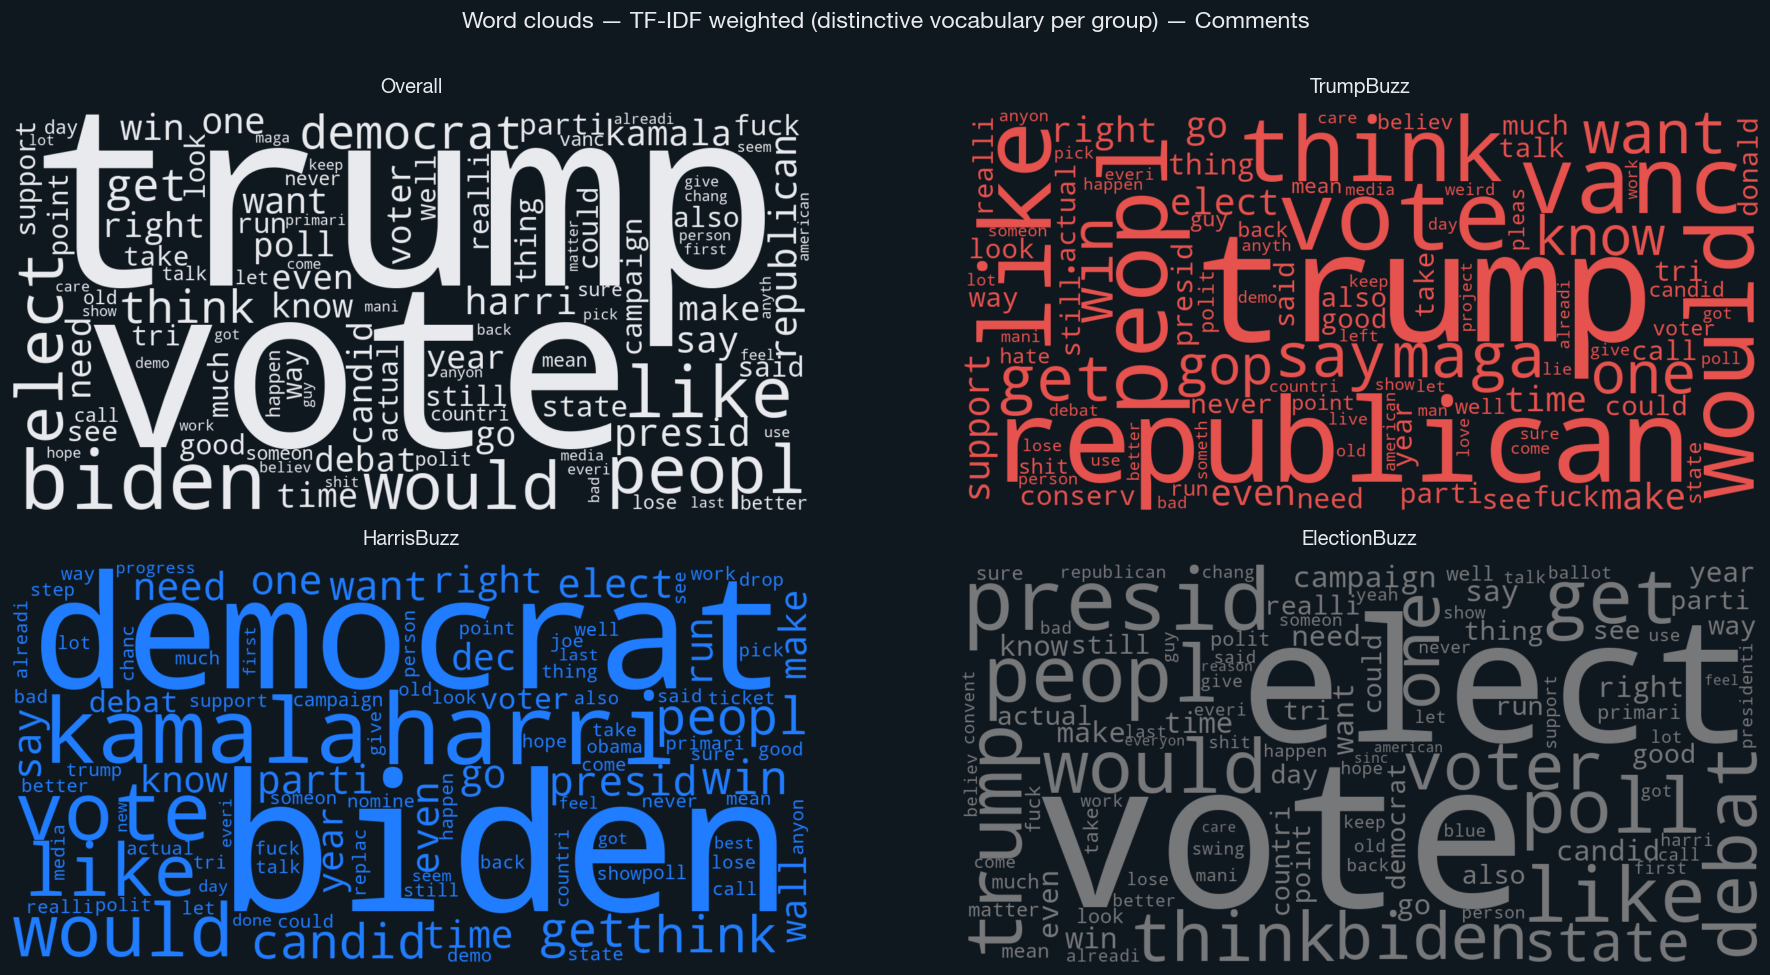

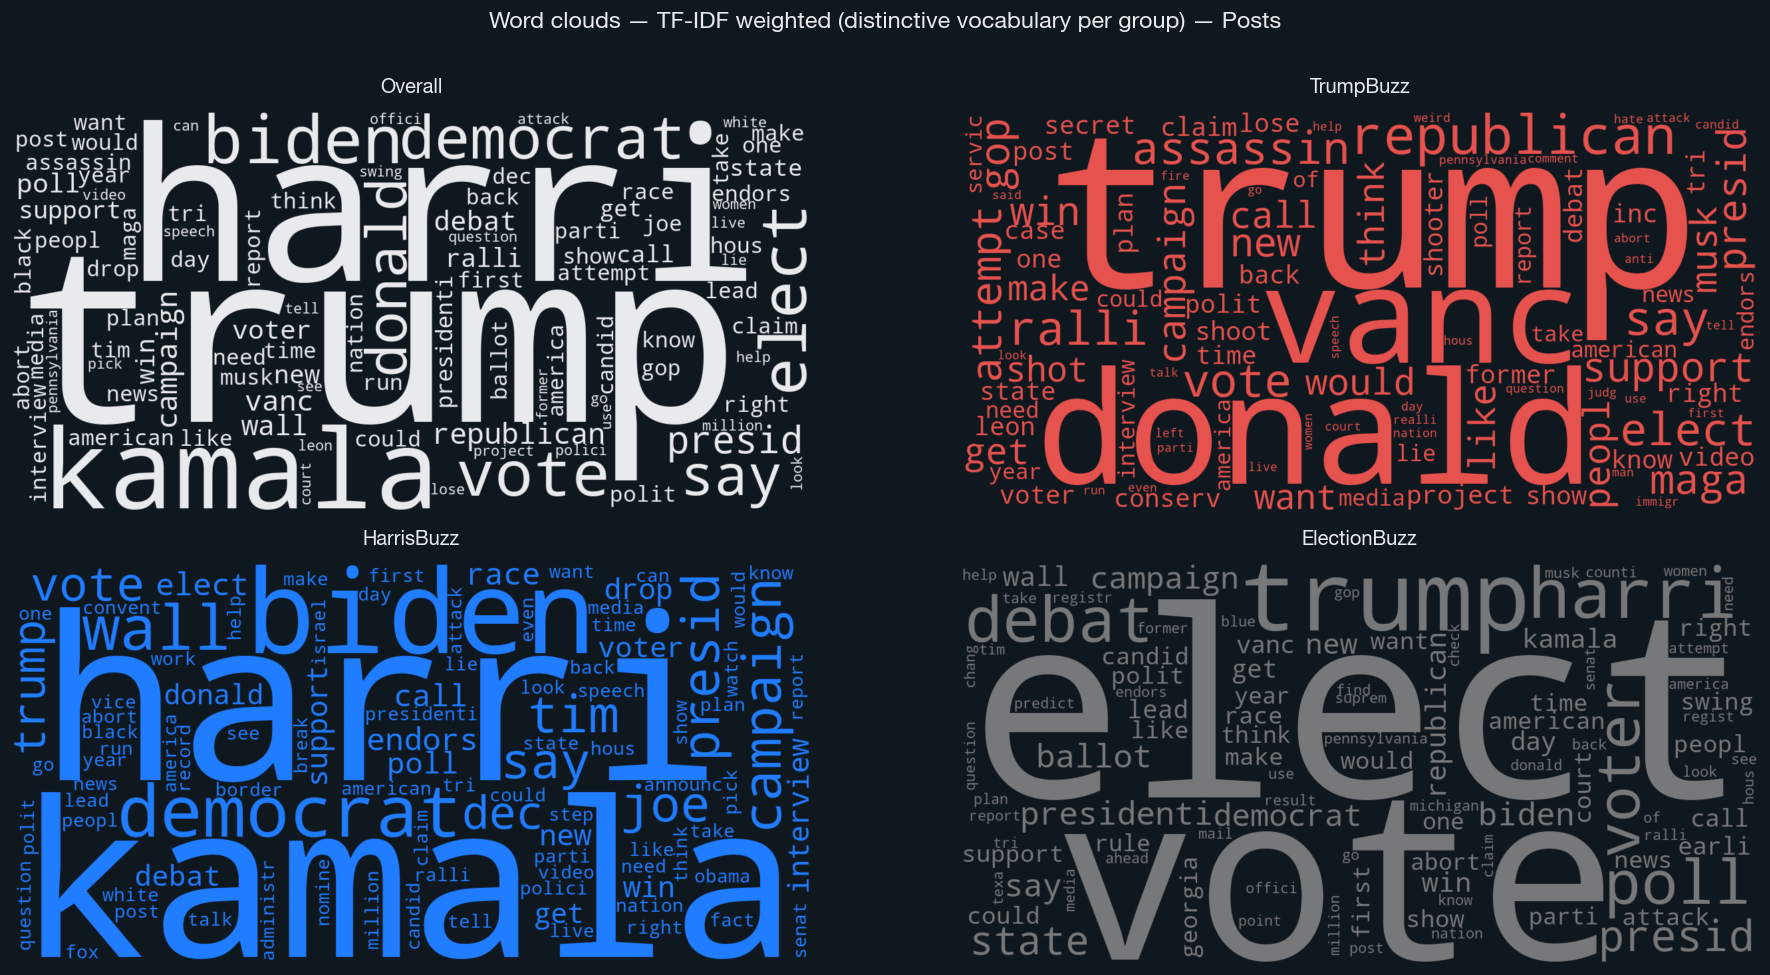

In [ ]:
WC_COLORS = {
    **BUZZ_COLORS,
    "Overall": OVERALL_BUZZ_COLOR,
}

def make_wc_tfidf(scores_dict, color):
    return WordCloud(
        width=1200, height=600,
        background_color=BG_DARK,
        max_words=100,
        collocations=False,
        color_func=lambda *args, **kwargs: color,
        relative_scaling=0.4,
        min_word_length=3,
    ).generate_from_frequencies(scores_dict)

def plot_wc_grid(wc_dict, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), facecolor=BG_DARK)
    for ax, (label, wc) in zip(axes.flat, wc_dict.items()):
        ax.set_facecolor(BG_DARK)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(label, fontsize=12, fontweight='bold', color=TEXT_PRIMARY)
    fig.suptitle(suptitle, fontsize=14, color=TEXT_PRIMARY,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

def tfidf_wordclouds(df, tfidf_matrix, feature_names, label):
    all_groups = {
        'Overall':      df,
        'TrumpBuzz':    df[df['candidate'] == 'TrumpBuzz'],
        'HarrisBuzz':   df[df['candidate'] == 'HarrisBuzz'],
        'ElectionBuzz': df[df['candidate'] == 'ElectionBuzz'],
    }

    wc_tfidf = {}
    for group_label, sub in all_groups.items():
        mask        = df.index.isin(sub.index)
        mean_scores = tfidf_matrix[mask].mean(axis=0).A1
        scores_dict = {
            feature_names[i]: mean_scores[i]
            for i in mean_scores.argsort()[::-1][:200]
        }
        wc_tfidf[group_label] = make_wc_tfidf(scores_dict, WC_COLORS[group_label])

    plot_wc_grid(
        wc_tfidf,
        f'Word clouds — TF-IDF weighted (distinctive vocabulary per group) — {label}'
    )

# ── Run for comments and posts ────────────────────────────────────────────────
tfidf_wordclouds(comments, tfidf_comments, feature_names_comments, label="Comments")
tfidf_wordclouds(posts,    tfidf_posts,    feature_names_posts,    label="Posts")